<a href="https://colab.research.google.com/github/Libelle210/Coffee_Finance/blob/main/wuhu_convlstm_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import zipfile
import os

zip_path = "/content/Wuhu_ConvLSTM.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("解压完成")
print(os.listdir("/content/Wuhu_ConvLSTM"))

解压完成
['drivers_norm', 'built', 'constraints']


In [ ]:
import os

base = "/content/Wuhu_ConvLSTM"

built = os.listdir(os.path.join(base, "built"))
drivers = os.listdir(os.path.join(base, "drivers_norm"))
water = os.path.join(base, "constraints", "devbound", "water.tif")

print("built 文件数：", len(built))
print("drivers 文件数：", len(drivers))
print("water.tif：", os.path.exists(water))

print("\n年度 built：")
print(sorted(built))

print("\ndrivers：")
print(sorted(drivers))

built 文件数： 21
drivers 文件数： 10
water.tif： True

年度 built：
['built_2000.tif', 'built_2001.tif', 'built_2002.tif', 'built_2003.tif', 'built_2004.tif', 'built_2005.tif', 'built_2006.tif', 'built_2007.tif', 'built_2008.tif', 'built_2009.tif', 'built_2010.tif', 'built_2011.tif', 'built_2012.tif', 'built_2013.tif', 'built_2014.tif', 'built_2015.tif', 'built_2016.tif', 'built_2017.tif', 'built_2018.tif', 'built_2019.tif', 'built_2020.tif']

drivers：
['dist_city_center_norm.tif', 'dist_road_motorway_norm.tif', 'dist_road_primary_norm.tif', 'dist_road_secondary_norm.tif', 'dist_road_trunk_norm.tif', 'dist_town_nearest_norm.tif', 'normalize_stats.json', 'poi_kernel_density_norm.tif', 'pop_density_2010_norm.tif', 'slope_deg_norm.tif']


In [ ]:
import os
import sys
import subprocess

# 检查 rasterio
try:
    import rasterio
    print("rasterio:", rasterio.__version__)
except ImportError:
    print("正在安装 rasterio...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "rasterio"])
    import rasterio
    print("rasterio:", rasterio.__version__)

rasterio: 1.5.2


In [ ]:
import rasterio
import os

BASE = "/content/Wuhu_ConvLSTM"

files_to_check = []

for year in range(2000, 2021):
    files_to_check.append(
        os.path.join(BASE, "built", f"built_{year}.tif")
    )

driver_names = [
    "slope_deg_norm.tif",
    "pop_density_2010_norm.tif",
    "dist_road_motorway_norm.tif",
    "dist_road_trunk_norm.tif",
    "dist_road_primary_norm.tif",
    "dist_road_secondary_norm.tif",
    "dist_city_center_norm.tif",
    "dist_town_nearest_norm.tif",
    "poi_kernel_density_norm.tif",
]

for name in driver_names:
    files_to_check.append(
        os.path.join(BASE, "drivers_norm", name)
    )

files_to_check.append(
    os.path.join(BASE, "constraints", "devbound", "water.tif")
)

reference = files_to_check[0]

with rasterio.open(reference) as src:
    ref_shape = (src.height, src.width)
    ref_transform = src.transform
    ref_bounds = src.bounds

print("基准：built_2000.tif")
print("shape:", ref_shape)
print("transform:", ref_transform)
print("bounds:", ref_bounds)
print()

all_ok = True

for path in files_to_check:
    with rasterio.open(path) as src:

        shape_ok = (src.height, src.width) == ref_shape
        transform_ok = src.transform == ref_transform
        bounds_ok = src.bounds == ref_bounds

        ok = shape_ok and transform_ok and bounds_ok

        if ok:
            print("✅", os.path.basename(path))
        else:
            print("❌", os.path.basename(path))
            print("   shape:", (src.height, src.width))
            print("   transform:", src.transform)
            print("   bounds:", src.bounds)

            if not shape_ok:
                print("   → 尺寸不同")
            if not transform_ok:
                print("   → 像元网格不同")
            if not bounds_ok:
                print("   → 空间范围不同")

            all_ok = False

print()

if all_ok:
    print("🎉 所有 31 个 GeoTIFF 的像元网格完全一致！")
else:
    print("⚠️ 仍存在真正的空间对齐问题。")

基准：built_2000.tif
shape: (3457, 4116)
transform: | 30.00, 0.00, 20543340.00|
| 0.00,-30.00, 3493470.00|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=20543340.0, bottom=3389760.0, right=20666820.0, top=3493470.0)

✅ built_2000.tif
✅ built_2001.tif
✅ built_2002.tif
✅ built_2003.tif
✅ built_2004.tif
✅ built_2005.tif
✅ built_2006.tif
✅ built_2007.tif
✅ built_2008.tif
✅ built_2009.tif
✅ built_2010.tif
✅ built_2011.tif
✅ built_2012.tif
✅ built_2013.tif
✅ built_2014.tif
✅ built_2015.tif
✅ built_2016.tif
✅ built_2017.tif
✅ built_2018.tif
✅ built_2019.tif
✅ built_2020.tif
✅ slope_deg_norm.tif
✅ pop_density_2010_norm.tif
✅ dist_road_motorway_norm.tif
✅ dist_road_trunk_norm.tif
✅ dist_road_primary_norm.tif
✅ dist_road_secondary_norm.tif
✅ dist_city_center_norm.tif
✅ dist_town_nearest_norm.tif
✅ poi_kernel_density_norm.tif
✅ water.tif

🎉 所有 31 个 GeoTIFF 的像元网格完全一致！


In [ ]:
import os
import numpy as np
import rasterio

BASE = "/content/Wuhu_ConvLSTM"

def check_raster(path, name):
    with rasterio.open(path) as src:
        data = src.read(1)
        nodata = src.nodata

        valid = data if nodata is None else data[data != nodata]

        print(f"\n{name}")
        print("-" * 50)
        print("dtype:", data.dtype)
        print("NoData:", nodata)
        print("最小值:", np.min(valid))
        print("最大值:", np.max(valid))
        print("均值:", np.mean(valid))
        print("唯一值数量:", len(np.unique(valid)))

        # 如果唯一值不多，直接显示
        unique = np.unique(valid)
        if len(unique) <= 20:
            print("唯一值:", unique)


# =========================
# 1. 检查 built
# =========================
print("=" * 60)
print("BUILT RASTERS")
print("=" * 60)

for year in range(2000, 2021):
    path = os.path.join(
        BASE, "built", f"built_{year}.tif"
    )
    check_raster(path, f"built_{year}.tif")


# =========================
# 2. 检查 drivers
# =========================
driver_names = [
    "slope_deg_norm.tif",
    "pop_density_2010_norm.tif",
    "dist_road_motorway_norm.tif",
    "dist_road_trunk_norm.tif",
    "dist_road_primary_norm.tif",
    "dist_road_secondary_norm.tif",
    "dist_city_center_norm.tif",
    "dist_town_nearest_norm.tif",
    "poi_kernel_density_norm.tif",
]

print("\n")
print("=" * 60)
print("STATIC DRIVERS")
print("=" * 60)

for name in driver_names:
    path = os.path.join(
        BASE, "drivers_norm", name
    )
    check_raster(path, name)


# =========================
# 3. 检查 water
# =========================
print("\n")
print("=" * 60)
print("WATER CONSTRAINT")
print("=" * 60)

water_path = os.path.join(
    BASE, "constraints", "devbound", "water.tif"
)

check_raster(water_path, "water.tif")

BUILT RASTERS

built_2000.tif
--------------------------------------------------
dtype: uint8
NoData: 255.0
最小值: 0
最大值: 1
均值: 0.035369936745407525
唯一值数量: 2
唯一值: [0 1]

built_2001.tif
--------------------------------------------------
dtype: uint8
NoData: 255.0
最小值: 0
最大值: 1
均值: 0.036043594288793716
唯一值数量: 2
唯一值: [0 1]

built_2002.tif
--------------------------------------------------
dtype: uint8
NoData: 255.0
最小值: 0
最大值: 1
均值: 0.03745201267551194
唯一值数量: 2
唯一值: [0 1]

built_2003.tif
--------------------------------------------------
dtype: uint8
NoData: 255.0
最小值: 0
最大值: 1
均值: 0.03883900687614957
唯一值数量: 2
唯一值: [0 1]

built_2004.tif
--------------------------------------------------
dtype: uint8
NoData: 255.0
最小值: 0
最大值: 1
均值: 0.04070329137615661
唯一值数量: 2
唯一值: [0 1]

built_2005.tif
--------------------------------------------------
dtype: uint8
NoData: 255.0
最小值: 0
最大值: 1
均值: 0.04174559704452719
唯一值数量: 2
唯一值: [0 1]

built_2006.tif
--------------------------------------------------
dtype

In [ ]:
import os
import numpy as np
import rasterio

BASE = "/content/Wuhu_ConvLSTM"

check_names = [
    ("slope_deg_norm.tif", os.path.join(BASE, "drivers_norm", "slope_deg_norm.tif")),
    ("pop_density_2010_norm.tif", os.path.join(BASE, "drivers_norm", "pop_density_2010_norm.tif")),
    ("dist_road_motorway_norm.tif", os.path.join(BASE, "drivers_norm", "dist_road_motorway_norm.tif")),
    ("poi_kernel_density_norm.tif", os.path.join(BASE, "drivers_norm", "poi_kernel_density_norm.tif")),
    ("water.tif", os.path.join(BASE, "constraints", "devbound", "water.tif")),
]

for name, path in check_names:
    with rasterio.open(path) as src:
        data = src.read(1)

        total = data.size
        nan_count = np.isnan(data).sum() if np.issubdtype(data.dtype, np.floating) else 0
        nodata_count = np.sum(data == src.nodata) if src.nodata is not None else 0
        finite = data[np.isfinite(data)]

        print("\n" + "=" * 60)
        print(name)
        print("=" * 60)
        print("dtype:", data.dtype)
        print("NoData 标记:", src.nodata)
        print("总像元:", total)
        print("NaN 数量:", nan_count)
        print("NaN 比例:", nan_count / total)
        print("NoData 数量:", nodata_count)
        print("NoData 比例:", nodata_count / total)

        if len(finite) > 0:
            print("有效有限值数量:", len(finite))
            print("有效值最小:", finite.min())
            print("有效值最大:", finite.max())
            print("有效值均值:", finite.mean())
        else:
            print("⚠️ 没有任何有限值！")


slope_deg_norm.tif
dtype: float32
NoData 标记: 255.0
总像元: 14229012
NaN 数量: 0
NaN 比例: 0.0
NoData 数量: 6340731
NoData 比例: 0.44561990670891277
有效有限值数量: 14229012
有效值最小: 0.0
有效值最大: 255.0
有效值均值: 113.658905

pop_density_2010_norm.tif
dtype: float32
NoData 标记: 255.0
总像元: 14229012
NaN 数量: 0
NaN 比例: 0.0
NoData 数量: 6340731
NoData 比例: 0.44561990670891277
有效有限值数量: 14229012
有效值最小: 0.0
有效值最大: 255.0
有效值均值: 113.63757

dist_road_motorway_norm.tif
dtype: float32
NoData 标记: 255.0
总像元: 14229012
NaN 数量: 0
NaN 比例: 0.0
NoData 数量: 6340731
NoData 比例: 0.44561990670891277
有效有限值数量: 14229012
有效值最小: 0.0
有效值最大: 255.0
有效值均值: 113.804726

poi_kernel_density_norm.tif
dtype: float32
NoData 标记: 255.0
总像元: 14229012
NaN 数量: 0
NaN 比例: 0.0
NoData 数量: 6340731
NoData 比例: 0.44561990670891277
有效有限值数量: 14229012
有效值最小: 0.0
有效值最大: 255.0
有效值均值: 113.64371

water.tif
dtype: uint8
NoData 标记: 255.0
总像元: 14229012
NaN 数量: 0
NaN 比例: 0.0
NoData 数量: 6340731
NoData 比例: 0.44561990670891277
有效有限值数量: 14229012
有效值最小: 0
有效值最大: 255
有效值均值: 113.676760621

In [ ]:
import os
import numpy as np
import rasterio

BASE = "/content/Wuhu_ConvLSTM"

driver_names = [
    "slope_deg_norm.tif",
    "pop_density_2010_norm.tif",
    "dist_road_motorway_norm.tif",
    "dist_road_trunk_norm.tif",
    "dist_road_primary_norm.tif",
    "dist_road_secondary_norm.tif",
    "dist_city_center_norm.tif",
    "dist_town_nearest_norm.tif",
    "poi_kernel_density_norm.tif",
]

for name in driver_names:

    path = os.path.join(BASE, "drivers_norm", name)

    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)

        # 有效像元：
        # 1. 不是 NaN
        # 2. 不是 NoData
        valid_mask = np.isfinite(data)

        if src.nodata is not None:
            valid_mask &= data != src.nodata

        valid = data[valid_mask]

        print("\n" + "=" * 55)
        print(name)
        print("=" * 55)

        print("总像元:", data.size)
        print("NaN:", np.isnan(data).sum())
        print("NoData:", np.sum(data == src.nodata))

        if len(valid) == 0:
            print("❌ 没有有效数据")
        else:
            print("有效像元:", len(valid))
            print("有效比例:", len(valid) / data.size)
            print("有效最小值:", valid.min())
            print("有效最大值:", valid.max())
            print("有效均值:", valid.mean())


slope_deg_norm.tif
总像元: 14229012
NaN: 0
NoData: 6340731
有效像元: 7888281
有效比例: 0.5543800932910873
有效最小值: 0.0
有效最大值: 1.0
有效均值: 0.046460006

pop_density_2010_norm.tif
总像元: 14229012
NaN: 0
NoData: 6340731
有效像元: 7888281
有效比例: 0.5543800932910873
有效最小值: 0.0
有效最大值: 1.0
有效均值: 0.007926962

dist_road_motorway_norm.tif
总像元: 14229012
NaN: 0
NoData: 6340731
有效像元: 7888281
有效比例: 0.5543800932910873
有效最小值: 0.0
有效最大值: 1.0
有效均值: 0.30962017

dist_road_trunk_norm.tif
总像元: 14229012
NaN: 0
NoData: 6340731
有效像元: 7888281
有效比例: 0.5543800932910873
有效最小值: 0.0
有效最大值: 1.0
有效均值: 0.30962017

dist_road_primary_norm.tif
总像元: 14229012
NaN: 0
NoData: 6340731
有效像元: 7888281
有效比例: 0.5543800932910873
有效最小值: 0.0
有效最大值: 1.0
有效均值: 0.30962017

dist_road_secondary_norm.tif
总像元: 14229012
NaN: 0
NoData: 6340731
有效像元: 7888281
有效比例: 0.5543800932910873
有效最小值: 0.0
有效最大值: 1.0
有效均值: 0.30962017

dist_city_center_norm.tif
总像元: 14229012
NaN: 0
NoData: 6340731
有效像元: 7888281
有效比例: 0.5543800932910873
有效最小值: 0.0
有效最大值: 1.0
有效均值: 0.3285843

dist_t

In [ ]:
import os
import rasterio

BASE = "/content/Wuhu_ConvLSTM"

built_dir = os.path.join(BASE, "built")

built_files = [
    os.path.join(built_dir, f"built_{year}.tif")
    for year in range(2000, 2021)
]

print("built 文件数量:", len(built_files))

for path in built_files:
    print(os.path.basename(path))

# 检查第一个和最后一个文件
with rasterio.open(built_files[0]) as src:
    print("\n2000年:")
    print("shape:", (src.height, src.width))
    print("dtype:", src.dtypes[0])
    print("CRS:", src.crs)
    print("分辨率:", src.res)
    print("NoData:", src.nodata)

with rasterio.open(built_files[-1]) as src:
    print("\n2020年:")
    print("shape:", (src.height, src.width))
    print("dtype:", src.dtypes[0])
    print("CRS:", src.crs)
    print("分辨率:", src.res)
    print("NoData:", src.nodata)

built 文件数量: 21
built_2000.tif
built_2001.tif
built_2002.tif
built_2003.tif
built_2004.tif
built_2005.tif
built_2006.tif
built_2007.tif
built_2008.tif
built_2009.tif
built_2010.tif
built_2011.tif
built_2012.tif
built_2013.tif
built_2014.tif
built_2015.tif
built_2016.tif
built_2017.tif
built_2018.tif
built_2019.tif
built_2020.tif

2000年:
shape: (3457, 4116)
dtype: uint8
CRS: PROJCS["CGCS2000 / Gauss-Kruger zone 20",GEOGCS["China Geodetic Coordinate System 2000",DATUM["China_2000",SPHEROID["CGCS2000",6378137,298.257222101004,AUTHORITY["EPSG","1024"]],AUTHORITY["EPSG","1043"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4490"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",1],PARAMETER["false_easting",20500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","4498"]]
分辨率: (

In [ ]:
import os
import numpy as np
import rasterio

BASE = "/content/Wuhu_ConvLSTM"

# =========================
# 1. 读取一个 128×128 样本
# =========================

row = 1000
col = 1000
tile_size = 128

# 读取 2000–2004 五年的 built
built_sequence = []

for year in range(2000, 2005):
    path = os.path.join(
        BASE,
        "built",
        f"built_{year}.tif"
    )

    with rasterio.open(path) as src:
        tile = src.read(
            1,
            window=rasterio.windows.Window(
                col,
                row,
                tile_size,
                tile_size
            )
        )

        # NoData 255 → 0
        tile = tile.astype(np.float32)
        tile[tile == 255] = 0

        built_sequence.append(tile)

built_sequence = np.stack(built_sequence, axis=0)


# =========================
# 2. 读取 2005 年目标
# =========================

target_path = os.path.join(
    BASE,
    "built",
    "built_2005.tif"
)

with rasterio.open(target_path) as src:
    target = src.read(
        1,
        window=rasterio.windows.Window(
            col,
            row,
            tile_size,
            tile_size
        )
    ).astype(np.float32)

target[target == 255] = 0


# =========================
# 3. 读取 9 个静态驱动
# =========================

driver_tiles = []

for name in driver_names:

    path = os.path.join(
        BASE,
        "drivers_norm",
        name
    )

    with rasterio.open(path) as src:

        tile = src.read(
            1,
            window=rasterio.windows.Window(
                col,
                row,
                tile_size,
                tile_size
            )
        ).astype(np.float32)

        driver_tiles.append(tile)

driver_tiles = np.stack(driver_tiles, axis=0)


# =========================
# 4. 组合输入
# =========================

# 5 个时间步
# 每个时间步：
# 1 个 built + 9 个静态驱动

X = np.zeros(
    (5, tile_size, tile_size, 10),
    dtype=np.float32
)

for t in range(5):

    # built
    X[t, :, :, 0] = built_sequence[t]

    # 9 个静态驱动
    X[t, :, :, 1:] = np.transpose(
        driver_tiles,
        (1, 2, 0)
    )


# 目标
y = target[..., np.newaxis]


# =========================
# 5. 输出检查
# =========================

print("================================")
print("ConvLSTM 样本检查")
print("================================")

print("X shape:", X.shape)
print("y shape:", y.shape)

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)

print("X min:", np.nanmin(X))
print("X max:", np.nanmax(X))

print("y min:", np.nanmin(y))
print("y max:", np.nanmax(y))

print("NaN in X:", np.isnan(X).sum())
print("NaN in y:", np.isnan(y).sum())

ConvLSTM 样本检查
X shape: (5, 128, 128, 10)
y shape: (128, 128, 1)
X dtype: float32
y dtype: float32
X min: 0.0
X max: 1.0
y min: 0.0
y max: 1.0
NaN in X: 0
NaN in y: 0


In [ ]:
import math
import tensorflow as tf

# =========================
# ConvLSTM 数据参数
# =========================

TILE_SIZE = 128
STRIDE = 64
TIME_STEPS = 5
CHANNELS = 10

HEIGHT = 3457
WIDTH = 4116


# =========================
# 计算空间 tile 位置
# =========================

tile_positions = []

for row in range(0, HEIGHT - TILE_SIZE + 1, STRIDE):
    for col in range(0, WIDTH - TILE_SIZE + 1, STRIDE):
        tile_positions.append((row, col))

print("空间 tile 数量:", len(tile_positions))

print("前5个位置:")
for p in tile_positions[:5]:
    print(p)

print("最后5个位置:")
for p in tile_positions[-5:]:
    print(p)

空间 tile 数量: 3339
前5个位置:
(0, 0)
(0, 64)
(0, 128)
(0, 192)
(0, 256)
最后5个位置:
(3328, 3712)
(3328, 3776)
(3328, 3840)
(3328, 3904)
(3328, 3968)


In [ ]:
import numpy as np
import rasterio
import tensorflow as tf
import os


class ConvLSTMDataGenerator(tf.keras.utils.Sequence):

    def __init__(
        self,
        base_dir,
        target_years,
        tile_positions,
        batch_size=4,
        tile_size=128,
        **kwargs
    ):
        super().__init__(**kwargs)
        self.base_dir = base_dir
        self.target_years = target_years
        self.tile_positions = tile_positions
        self.batch_size = batch_size
        self.tile_size = tile_size

        # 9 个静态驱动
        self.driver_names = [
            "slope_deg_norm.tif",
            "pop_density_2010_norm.tif",
            "dist_road_motorway_norm.tif",
            "dist_road_trunk_norm.tif",
            "dist_road_primary_norm.tif",
            "dist_road_secondary_norm.tif",
            "dist_city_center_norm.tif",
            "dist_town_nearest_norm.tif",
            "poi_kernel_density_norm.tif",
        ]

        # 所有样本
        self.samples = []

        for year in target_years:
            for row, col in tile_positions:
                self.samples.append(
                    (year, row, col)
                )

    def __len__(self):

        return int(
            np.ceil(
                len(self.samples) / self.batch_size
            )
        )

    def __getitem__(self, index):

        batch_samples = self.samples[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        X = np.zeros(
            (
                len(batch_samples),
                5,
                self.tile_size,
                self.tile_size,
                10
            ),
            dtype=np.float32
        )

        y = np.zeros(
            (
                len(batch_samples),
                self.tile_size,
                self.tile_size,
                1
            ),
            dtype=np.float32
        )

        # =========================
        # 读取 batch
        # =========================

        for i, (target_year, row, col) in enumerate(batch_samples):

            window = rasterio.windows.Window(
                col,
                row,
                self.tile_size,
                self.tile_size
            )

            # -------------------------
            # 5 年 built
            # -------------------------

            for t, year in enumerate(
                range(target_year - 5, target_year)
            ):

                path = os.path.join(
                    self.base_dir,
                    "built",
                    f"built_{year}.tif"
                )

                with rasterio.open(path) as src:

                    tile = src.read(
                        1,
                        window=window
                    ).astype(np.float32)

                # NoData 255 → 0
                tile[tile == 255] = 0

                X[i, t, :, :, 0] = tile

            # -------------------------
            # 9 个静态驱动
            # -------------------------

            for d, name in enumerate(
                self.driver_names
            ):

                path = os.path.join(
                    self.base_dir,
                    "drivers_norm",
                    name
                )

                with rasterio.open(path) as src:

                    tile = src.read(
                        1,
                        window=window
                    ).astype(np.float32)

                # NaN → 0
                tile = np.nan_to_num(
                    tile,
                    nan=0.0
                )

                # NoData → 0
                if src.nodata is not None:
                    tile[tile == src.nodata] = 0

                # 重复到5个时间步
                X[
                    i,
                    :,
                    :,
                    :,
                    d + 1
                ] = tile

            # -------------------------
            # 目标年份
            # -------------------------

            target_path = os.path.join(
                self.base_dir,
                "built",
                f"built_{target_year}.tif"
            )

            with rasterio.open(target_path) as src:

                target = src.read(
                    1,
                    window=window
                ).astype(np.float32)

            target[target == 255] = 0

            y[i, :, :, 0] = target

        return X, y

In [ ]:
# =========================
# 创建训练 Generator
# =========================

train_years = list(range(2005, 2016))

train_gen = ConvLSTMDataGenerator(
    base_dir=BASE,
    target_years=train_years,
    tile_positions=tile_positions,
    batch_size=4,
    tile_size=128
)

print("训练样本数:", len(train_gen.samples))
print("训练 batch 数:", len(train_gen))


# =========================
# 创建验证 Generator
# =========================

val_years = list(range(2016, 2021))

val_gen = ConvLSTMDataGenerator(
    base_dir=BASE,
    target_years=val_years,
    tile_positions=tile_positions,
    batch_size=4,
    tile_size=128
)

print("验证样本数:", len(val_gen.samples))
print("验证 batch 数:", len(val_gen))

训练样本数: 36729
训练 batch 数: 9183
验证样本数: 16695
验证 batch 数: 4174


In [ ]:
# =========================
# Generator 实际读取测试
# =========================

X_batch, y_batch = train_gen[0]

print("================================")
print("Generator Batch 检查")
print("================================")

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

print("X dtype:", X_batch.dtype)
print("y dtype:", y_batch.dtype)

print("X min:", np.nanmin(X_batch))
print("X max:", np.nanmax(X_batch))

print("y min:", np.nanmin(y_batch))
print("y max:", np.nanmax(y_batch))

print("X NaN:", np.isnan(X_batch).sum())
print("y NaN:", np.isnan(y_batch).sum())

print("X Inf:", np.isinf(X_batch).sum())
print("y Inf:", np.isinf(y_batch).sum())

Generator Batch 检查
X batch shape: (4, 5, 128, 128, 10)
y batch shape: (4, 128, 128, 1)
X dtype: float32
y dtype: float32
X min: 0.0
X max: 0.0
y min: 0.0
y max: 0.0
X NaN: 0
y NaN: 0
X Inf: 0
y Inf: 0


In [ ]:
# ==========================================
# 检查几个不同位置的 tile
# ==========================================

test_positions = [
    (0, 0),
    (1000, 1000),
    (2000, 2000),
    (3000, 3000),
]

for row, col in test_positions:

    print("\n" + "=" * 60)
    print("位置:", row, col)

    window = rasterio.windows.Window(
        col,
        row,
        128,
        128
    )

    # 检查 2020 built
    built_path = os.path.join(
        BASE,
        "built",
        "built_2020.tif"
    )

    with rasterio.open(built_path) as src:
        built = src.read(1, window=window).astype(np.float32)

    built[built == 255] = 0

    print("built:")
    print("  min =", built.min())
    print("  max =", built.max())
    print("  mean =", built.mean())
    print("  非零像元 =", np.count_nonzero(built))

    # 检查 slope
    slope_path = os.path.join(
        BASE,
        "drivers_norm",
        "slope_deg_norm.tif"
    )

    with rasterio.open(slope_path) as src:
        slope = src.read(1, window=window).astype(np.float32)

    slope = np.nan_to_num(slope, nan=0.0)

    if src.nodata is not None:
        slope[slope == src.nodata] = 0

    print("slope:")
    print("  min =", slope.min())
    print("  max =", slope.max())
    print("  mean =", slope.mean())
    print("  非零像元 =", np.count_nonzero(slope))

    # 检查 POI
    poi_path = os.path.join(
        BASE,
        "drivers_norm",
        "poi_kernel_density_norm.tif"
    )

    with rasterio.open(poi_path) as src:
        poi = src.read(1, window=window).astype(np.float32)

    poi = np.nan_to_num(poi, nan=0.0)

    if src.nodata is not None:
        poi[poi == src.nodata] = 0

    print("POI:")
    print("  min =", poi.min())
    print("  max =", poi.max())
    print("  mean =", poi.mean())
    print("  非零像元 =", np.count_nonzero(poi))


位置: 0 0
built:
  min = 0.0
  max = 0.0
  mean = 0.0
  非零像元 = 0
slope:
  min = 0.0
  max = 0.0
  mean = 0.0
  非零像元 = 0
POI:
  min = 0.0
  max = 0.0
  mean = 0.0
  非零像元 = 0

位置: 1000 1000
built:
  min = 0.0
  max = 1.0
  mean = 0.05053711
  非零像元 = 828
slope:
  min = 0.0
  max = 0.10760168
  mean = 0.014638368
  非零像元 = 16185
POI:
  min = 2.7254451e-05
  max = 0.006953061
  mean = 0.0013419217
  非零像元 = 16384

位置: 2000 2000
built:
  min = 0.0
  max = 1.0
  mean = 0.021911621
  非零像元 = 359
slope:
  min = 0.0
  max = 0.50390613
  mean = 0.1271871
  非零像元 = 16380
POI:
  min = 2.3412858e-06
  max = 0.011093811
  mean = 0.0021469803
  非零像元 = 16384

位置: 3000 3000
built:
  min = 0.0
  max = 0.0
  mean = 0.0
  非零像元 = 0
slope:
  min = 0.0
  max = 0.0
  mean = 0.0
  非零像元 = 0
POI:
  min = 0.0
  max = 0.0
  mean = 0.0
  非零像元 = 0


In [ ]:
# ==========================================
# 统计每个目标年份有多少有效 tile
# ==========================================

def count_valid_tiles(target_year):

    valid_count = 0
    empty_count = 0

    for row, col in tile_positions:

        window = rasterio.windows.Window(
            col,
            row,
            TILE_SIZE,
            TILE_SIZE
        )

        # 读取目标年份 built
        path = os.path.join(
            BASE,
            "built",
            f"built_{target_year}.tif"
        )

        with rasterio.open(path) as src:
            tile = src.read(
                1,
                window=window
            )

        # 去掉 NoData
        tile = tile[tile != 255]

        # 至少有一个 built 像元
        if len(tile) > 0 and np.any(tile == 1):
            valid_count += 1
        else:
            empty_count += 1

    return valid_count, empty_count


print("========================================")
print("各目标年份有效 tile 统计")
print("========================================")

for year in range(2005, 2021):

    valid, empty = count_valid_tiles(year)

    print(
        f"{year}: "
        f"有效 {valid}, "
        f"空白 {empty}, "
        f"总计 {valid + empty}"
    )

各目标年份有效 tile 统计
2005: 有效 2134, 空白 1205, 总计 3339
2006: 有效 2134, 空白 1205, 总计 3339
2007: 有效 2136, 空白 1203, 总计 3339
2008: 有效 2136, 空白 1203, 总计 3339
2009: 有效 2136, 空白 1203, 总计 3339
2010: 有效 2137, 空白 1202, 总计 3339
2011: 有效 2137, 空白 1202, 总计 3339
2012: 有效 2138, 空白 1201, 总计 3339
2013: 有效 2143, 空白 1196, 总计 3339
2014: 有效 2145, 空白 1194, 总计 3339
2015: 有效 2146, 空白 1193, 总计 3339
2016: 有效 2146, 空白 1193, 总计 3339
2017: 有效 2147, 空白 1192, 总计 3339
2018: 有效 2147, 空白 1192, 总计 3339
2019: 有效 2147, 空白 1192, 总计 3339
2020: 有效 2147, 空白 1192, 总计 3339


In [ ]:
# ==========================================
# 建立整个研究时期的有效空间 tile
# ==========================================

valid_tile_positions = []

for row, col in tile_positions:

    has_built = False

    window = rasterio.windows.Window(
        col,
        row,
        TILE_SIZE,
        TILE_SIZE
    )

    # 检查 2000–2020 是否至少有一年存在 built
    for year in range(2000, 2021):

        path = os.path.join(
            BASE,
            "built",
            f"built_{year}.tif"
        )

        with rasterio.open(path) as src:

            tile = src.read(
                1,
                window=window
            )

        tile = tile[tile != 255]

        if len(tile) > 0 and np.any(tile == 1):
            has_built = True
            break

    if has_built:
        valid_tile_positions.append((row, col))


print("========================================")
print("有效空间 tile")
print("========================================")

print("原始 tile 数:", len(tile_positions))
print("有效 tile 数:", len(valid_tile_positions))
print("排除 tile 数:", len(tile_positions) - len(valid_tile_positions))
print(
    "有效比例:",
    len(valid_tile_positions) / len(tile_positions)
)

有效空间 tile
原始 tile 数: 3339
有效 tile 数: 2147
排除 tile 数: 1192
有效比例: 0.6430068882899072


In [ ]:
# ==========================================
# 使用有效空间 tile 重新建立训练/验证 Generator
# ==========================================

train_years = list(range(2005, 2016))
val_years = list(range(2016, 2021))

# -------------------------
# 训练 Generator
# -------------------------

train_gen = ConvLSTMDataGenerator(
    base_dir=BASE,
    target_years=train_years,
    tile_positions=valid_tile_positions,
    batch_size=4,
    tile_size=128
)

# -------------------------
# 验证 Generator
# -------------------------

val_gen = ConvLSTMDataGenerator(
    base_dir=BASE,
    target_years=val_years,
    tile_positions=valid_tile_positions,
    batch_size=4,
    tile_size=128
)

print("================================")
print("新的 Generator")
print("================================")

print("训练样本数:", len(train_gen.samples))
print("训练 batch 数:", len(train_gen))

print("验证样本数:", len(val_gen.samples))
print("验证 batch 数:", len(val_gen))

新的 Generator
训练样本数: 23617
训练 batch 数: 5905
验证样本数: 10735
验证 batch 数: 2684


In [ ]:
# ==========================================
# 检查新的第一个 batch
# ==========================================

X_batch, y_batch = train_gen[0]

print("================================")
print("新的 Generator Batch 检查")
print("================================")

print("X batch shape:", X_batch.shape)
print("y batch shape:", y_batch.shape)

print("X min:", X_batch.min())
print("X max:", X_batch.max())

print("y min:", y_batch.min())
print("y max:", y_batch.max())

print("X NaN:", np.isnan(X_batch).sum())
print("y NaN:", np.isnan(y_batch).sum())

print("X Inf:", np.isinf(X_batch).sum())
print("y Inf:", np.isinf(y_batch).sum())

print("X 非零像元:", np.count_nonzero(X_batch))
print("y 非零像元:", np.count_nonzero(y_batch))

新的 Generator Batch 检查
X batch shape: (4, 5, 128, 128, 10)
y batch shape: (4, 128, 128, 1)
X min: 0.0
X max: 1.0
y min: 0.0
y max: 1.0
X NaN: 0
y NaN: 0
X Inf: 0
y Inf: 0
X 非零像元: 1263549
y 非零像元: 1425


下一步：建立 ConvLSTM 模型

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# ConvLSTM 模型
# ==========================================

model = models.Sequential([

    # 输入：
    # 5个时间步
    # 128×128空间尺寸
    # 10个通道
    layers.Input(
        shape=(5, 128, 128, 10)
    ),

    # 第一层 ConvLSTM
    layers.ConvLSTM2D(
        filters=16,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True
    ),

    # 第二层 ConvLSTM
    layers.ConvLSTM2D(
        filters=8,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False
    ),

    # 1×1卷积输出
    layers.Conv2D(
        filters=1,
        kernel_size=(1, 1),
        activation="sigmoid",
        padding="same"
    )
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 5, 128, 128,    │        15,040 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)      │ (None, 128, 128, 8)    │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 1)    │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,993 (85.91 KB)

 Trainable params: 21,993 (85.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf


# ==========================================
# Dice Loss
# ==========================================

def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Dice Loss = 1 - Dice Coefficient
    """

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # 展平空间维度
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    dice = (
        2.0 * intersection + smooth
    ) / (
        tf.reduce_sum(y_true_f)
        + tf.reduce_sum(y_pred_f)
        + smooth
    )

    return 1.0 - dice


# ==========================================
# Weighted Binary Cross Entropy
# ==========================================

# 建设用地类别权重
POS_WEIGHT = 5.0


def weighted_bce(y_true, y_pred):
    """
    Weighted Binary Cross Entropy

    对建设用地（y=1）给予更高权重。
    """

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # 防止 log(0)
    eps = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(
        y_pred,
        eps,
        1.0 - eps
    )

    loss = -(
        POS_WEIGHT * y_true * tf.math.log(y_pred)
        +
        (1.0 - y_true) * tf.math.log(1.0 - y_pred)
    )

    return tf.reduce_mean(loss)


# ==========================================
# Dice + Weighted BCE
# ==========================================

def combined_loss(y_true, y_pred):

    dice = dice_loss(y_true, y_pred)

    bce = weighted_bce(y_true, y_pred)

    return dice + bce

In [ ]:
# ==========================================
# 测试 Loss
# ==========================================

X_test, y_test = train_gen[0]

y_pred_test = model(X_test, training=False)

loss_value = combined_loss(
    y_test,
    y_pred_test
)

print("X shape:", X_test.shape)
print("y shape:", y_test.shape)
print("预测 shape:", y_pred_test.shape)
print("Loss:", float(loss_value))

X shape: (4, 5, 128, 128, 10)
y shape: (4, 128, 128, 1)
预测 shape: (4, 128, 128, 1)
Loss: 1.7102726697921753


In [ ]:
# ==========================================
# 编译 ConvLSTM 模型
# ==========================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

model.compile(
    optimizer=optimizer,
    loss=combined_loss,
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

print("模型编译完成")
print("Optimizer: Adam")
print("Learning rate: 1e-3")
print("Loss: Dice Loss + Weighted BCE")

模型编译完成
Optimizer: Adam
Learning rate: 1e-3
Loss: Dice Loss + Weighted BCE


In [ ]:
# ==========================================
# GPU Smoke Test
# ==========================================

print("开始 Smoke Test...")

history_test = model.fit(
    train_gen,
    epochs=1,
    steps_per_epoch=5,
    verbose=1
)

print("Smoke Test 完成")

开始 Smoke Test...
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 257ms/step - accuracy: 0.7854 - loss: 1.6918
Smoke Test 完成


In [ ]:
train_gen = ConvLSTMDataGenerator(
    BASE,
    train_years,
    valid_tile_positions,
    batch_size=4,
    tile_size=128
)

val_gen = ConvLSTMDataGenerator(
    BASE,
    val_years,
    valid_tile_positions,
    batch_size=4,
    tile_size=128
)

print("Train samples:", len(train_gen.samples))
print("Train batches:", len(train_gen))

print("Val samples:", len(val_gen.samples))
print("Val batches:", len(val_gen))

Train samples: 23617
Train batches: 5905
Val samples: 10735
Val batches: 2684


In [ ]:
import os
import time
import gc
import numpy as np
import rasterio


BASE = "/content/Wuhu_ConvLSTM"


# ==========================================
# 9 个静态驱动
# ==========================================

driver_names = [
    "slope_deg_norm.tif",
    "pop_density_2010_norm.tif",
    "dist_road_motorway_norm.tif",
    "dist_road_trunk_norm.tif",
    "dist_road_primary_norm.tif",
    "dist_road_secondary_norm.tif",
    "dist_city_center_norm.tif",
    "dist_town_nearest_norm.tif",
    "poi_kernel_density_norm.tif",
]


# ==========================================
# 建立数据缓存
# ==========================================

class ConvLSTMDataCache:

    def __init__(self, base_dir):

        self.base_dir = base_dir

        print("开始加载数据到 RAM...")
        start_time = time.time()

        # ----------------------------------
        # 1. 加载 2000-2020 Built
        # ----------------------------------

        self.built = {}

        for year in range(2000, 2021):

            path = os.path.join(
                base_dir,
                "built",
                f"built_{year}.tif"
            )

            with rasterio.open(path) as src:

                arr = src.read(1)

                # NoData 255 → 0
                if src.nodata is not None:
                    arr[arr == src.nodata] = 0

                # 保持 uint8，节省 RAM
                arr = arr.astype(np.uint8)

                self.built[year] = arr

        print("Built 数据加载完成")


        # ----------------------------------
        # 2. 加载 9 个静态驱动
        # ----------------------------------

        driver_arrays = []

        for name in driver_names:

            path = os.path.join(
                base_dir,
                "drivers_norm",
                name
            )

            with rasterio.open(path) as src:

                arr = src.read(1).astype(np.float32)

                # NoData → 0
                if src.nodata is not None:
                    arr[arr == src.nodata] = 0

                # NaN / Inf → 0
                arr = np.nan_to_num(
                    arr,
                    nan=0.0,
                    posinf=0.0,
                    neginf=0.0
                )

                driver_arrays.append(arr)

        # shape:
        # (9, 3457, 4116)
        self.drivers = np.stack(
            driver_arrays,
            axis=0
        ).astype(np.float32)

        print("静态驱动加载完成")

        elapsed = time.time() - start_time

        print(f"\n数据缓存完成，用时: {elapsed:.2f} 秒")

        print("Built 年份:", len(self.built))
        print("Drivers shape:", self.drivers.shape)

        print(
            "RAM 中主要数组大小约:",
            round(
                self.drivers.nbytes / 1024**3,
                2
            ),
            "GB"
        )

In [ ]:
# ==========================================
# 创建缓存
# ==========================================

# 释放旧 Generator
try:
    del train_gen
    del val_gen
except:
    pass

gc.collect()


cache = ConvLSTMDataCache(BASE)

开始加载数据到 RAM...
Built 数据加载完成
静态驱动加载完成

数据缓存完成，用时: 5.11 秒
Built 年份: 21
Drivers shape: (9, 3457, 4116)
RAM 中主要数组大小约: 0.48 GB


In [ ]:
# ==========================================
# 高速 ConvLSTM Generator
# ==========================================

class FastConvLSTMDataGenerator(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        cache,
        target_years,
        tile_positions,
        batch_size=4,
        tile_size=128,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.cache = cache
        self.target_years = target_years
        self.tile_positions = tile_positions
        self.batch_size = batch_size
        self.tile_size = tile_size

        self.samples = [
            (year, row, col)
            for year in target_years
            for row, col in tile_positions
        ]


    def __len__(self):

        return int(
            np.ceil(
                len(self.samples)
                / self.batch_size
            )
        )


    def __getitem__(self, index):

        batch_samples = self.samples[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        batch_size_actual = len(batch_samples)

        # ----------------------------------
        # X:
        # (batch, 5, 128, 128, 10)
        # ----------------------------------

        X = np.zeros(
            (
                batch_size_actual,
                5,
                self.tile_size,
                self.tile_size,
                10
            ),
            dtype=np.float32
        )

        # ----------------------------------
        # y:
        # (batch, 128, 128, 1)
        # ----------------------------------

        y = np.zeros(
            (
                batch_size_actual,
                self.tile_size,
                self.tile_size,
                1
            ),
            dtype=np.float32
        )


        # ==================================
        # 逐样本构造
        # ==================================

        for b, (target_year, row, col) in enumerate(
            batch_samples
        ):

            r1 = row
            r2 = row + self.tile_size

            c1 = col
            c2 = col + self.tile_size


            # ----------------------------------
            # 静态驱动 tile
            #
            # 原始:
            # (9, 128, 128)
            #
            # 转换后:
            # (128, 128, 9)
            # ----------------------------------

            driver_tile = self.cache.drivers[
                :,
                r1:r2,
                c1:c2
            ]

            driver_tile = np.moveaxis(
                driver_tile,
                0,
                -1
            )


            # ----------------------------------
            # 连续 5 年输入
            # ----------------------------------

            input_years = range(
                target_year - 5,
                target_year
            )

            for t, year in enumerate(
                input_years
            ):

                # 第 0 通道 = Built
                X[
                    b,
                    t,
                    :, :,
                    0
                ] = self.cache.built[year][
                    r1:r2,
                    c1:c2
                ]

                # 第 1-9 通道 = 静态驱动
                X[
                    b,
                    t,
                    :, :,
                    1:
                ] = driver_tile


            # ----------------------------------
            # 目标年份
            # ----------------------------------

            y[
                b,
                :, :,
                0
            ] = self.cache.built[target_year][
                r1:r2,
                c1:c2
            ]


        return X, y

In [ ]:
# ==========================================
# 创建高速 Generator
# ==========================================

train_gen_fast = FastConvLSTMDataGenerator(
    cache,
    train_years,
    valid_tile_positions,
    batch_size=4,
    tile_size=128
)

val_gen_fast = FastConvLSTMDataGenerator(
    cache,
    val_years,
    valid_tile_positions,
    batch_size=4,
    tile_size=128
)


print("Train samples:", len(train_gen_fast.samples))
print("Train batches:", len(train_gen_fast))

print("Val samples:", len(val_gen_fast.samples))
print("Val batches:", len(val_gen_fast))

Train samples: 23617
Train batches: 5905
Val samples: 10735
Val batches: 2684


In [ ]:
# ==========================================
# 测试高速 Generator
# ==========================================

X_fast, y_fast = train_gen_fast[0]

print("X shape:", X_fast.shape)
print("y shape:", y_fast.shape)

print("X min:", X_fast.min())
print("X max:", X_fast.max())

print("y min:", y_fast.min())
print("y max:", y_fast.max())

print("X NaN:", np.isnan(X_fast).sum())
print("y NaN:", np.isnan(y_fast).sum())

print("X Inf:", np.isinf(X_fast).sum())
print("y Inf:", np.isinf(y_fast).sum())

print("X 非零像元:", np.count_nonzero(X_fast))
print("y 非零像元:", np.count_nonzero(y_fast))

X shape: (4, 5, 128, 128, 10)
y shape: (4, 128, 128, 1)
X min: 0.0
X max: 1.0
y min: 0.0
y max: 1.0
X NaN: 0
y NaN: 0
X Inf: 0
y Inf: 0
X 非零像元: 1263549
y 非零像元: 1425


In [ ]:
# ==========================================
# 测试读取速度
# ==========================================

import time

start = time.time()

for i in range(5):
    X_tmp, y_tmp = train_gen_fast[i]

elapsed = time.time() - start

print(
    f"5 个 batch 数据读取耗时: {elapsed:.3f} 秒"
)

print(
    f"平均每 batch: {elapsed / 5:.3f} 秒"
)

5 个 batch 数据读取耗时: 0.054 秒
平均每 batch: 0.011 秒


In [ ]:
class FastConvLSTMDataGenerator(
    tf.keras.utils.Sequence
):

    def __init__(
        self,
        cache,
        target_years,
        tile_positions,
        batch_size=4,
        tile_size=128,
        augment=False,
        **kwargs
    ):

        super().__init__(**kwargs)

        self.cache = cache
        self.target_years = target_years
        self.tile_positions = tile_positions
        self.batch_size = batch_size
        self.tile_size = tile_size
        self.augment = augment

        self.samples = [
            (year, row, col)
            for year in target_years
            for row, col in tile_positions
        ]


    def __len__(self):

        return int(
            np.ceil(
                len(self.samples)
                / self.batch_size
            )
        )


    def __getitem__(self, index):

        batch_samples = self.samples[
            index * self.batch_size:
            (index + 1) * self.batch_size
        ]

        batch_size_actual = len(batch_samples)

        X = np.zeros(
            (
                batch_size_actual,
                5,
                self.tile_size,
                self.tile_size,
                10
            ),
            dtype=np.float32
        )

        y = np.zeros(
            (
                batch_size_actual,
                self.tile_size,
                self.tile_size,
                1
            ),
            dtype=np.float32
        )


        # ==================================
        # 构造 batch
        # ==================================

        for b, (target_year, row, col) in enumerate(
            batch_samples
        ):

            r1 = row
            r2 = row + self.tile_size

            c1 = col
            c2 = col + self.tile_size


            # ----------------------------------
            # 9 个静态驱动
            # ----------------------------------

            driver_tile = self.cache.drivers[
                :,
                r1:r2,
                c1:c2
            ]

            driver_tile = np.moveaxis(
                driver_tile,
                0,
                -1
            )


            # ----------------------------------
            # 过去 5 年
            # ----------------------------------

            input_years = range(
                target_year - 5,
                target_year
            )

            for t, year in enumerate(
                input_years
            ):

                # Built
                X[
                    b,
                    t,
                    :, :,
                    0
                ] = self.cache.built[year][
                    r1:r2,
                    c1:c2
                ]

                # 9 个静态驱动
                X[
                    b,
                    t,
                    :, :,
                    1:
                ] = driver_tile


            # ----------------------------------
            # 目标年份
            # ----------------------------------

            y[
                b,
                :, :,
                0
            ] = self.cache.built[target_year][
                r1:r2,
                c1:c2
            ]


            # ==================================
            # 数据增强
            # ==================================

            if self.augment:

                # 随机选择一种变换
                transform = np.random.randint(0, 7)

                # ------------------------------
                # 0 = 不变
                # ------------------------------
                if transform == 0:
                    pass

                # ------------------------------
                # 1 = 旋转 90°
                # ------------------------------
                elif transform == 1:

                    X[b] = np.rot90(
                        X[b],
                        k=1,
                        axes=(1, 2)
                    )

                    y[b] = np.rot90(
                        y[b],
                        k=1,
                        axes=(0, 1)
                    )

                # ------------------------------
                # 2 = 旋转 180°
                # ------------------------------
                elif transform == 2:

                    X[b] = np.rot90(
                        X[b],
                        k=2,
                        axes=(1, 2)
                    )

                    y[b] = np.rot90(
                        y[b],
                        k=2,
                        axes=(0, 1)
                    )

                # ------------------------------
                # 3 = 旋转 270°
                # ------------------------------
                elif transform == 3:

                    X[b] = np.rot90(
                        X[b],
                        k=3,
                        axes=(1, 2)
                    )

                    y[b] = np.rot90(
                        y[b],
                        k=3,
                        axes=(0, 1)
                    )

                # ------------------------------
                # 4 = 水平翻转
                # ------------------------------
                elif transform == 4:

                    X[b] = np.flip(
                        X[b],
                        axis=2
                    )

                    y[b] = np.flip(
                        y[b],
                        axis=1
                    )

                # ------------------------------
                # 5 = 垂直翻转
                # ------------------------------
                elif transform == 5:

                    X[b] = np.flip(
                        X[b],
                        axis=1
                    )

                    y[b] = np.flip(
                        y[b],
                        axis=0
                    )

                # ------------------------------
                # 6 = 同时水平 + 垂直翻转
                # ------------------------------
                elif transform == 6:

                    X[b] = np.flip(
                        X[b],
                        axis=(1, 2)
                    )

                    y[b] = np.flip(
                        y[b],
                        axis=(0, 1)
                    )


        return X, y

In [ ]:
train_gen_fast = FastConvLSTMDataGenerator(
    cache,
    train_years,
    valid_tile_positions,
    batch_size=4,
    tile_size=128,
    augment=True
)

val_gen_fast = FastConvLSTMDataGenerator(
    cache,
    val_years,
    valid_tile_positions,
    batch_size=4,
    tile_size=128,
    augment=False
)

print("Train samples:", len(train_gen_fast.samples))
print("Train batches:", len(train_gen_fast))

print("Val samples:", len(val_gen_fast.samples))
print("Val batches:", len(val_gen_fast))

Train samples: 23617
Train batches: 5905
Val samples: 10735
Val batches: 2684


In [ ]:
X_aug, y_aug = train_gen_fast[0]

print("X shape:", X_aug.shape)
print("y shape:", y_aug.shape)

print("X min:", X_aug.min())
print("X max:", X_aug.max())

print("y min:", y_aug.min())
print("y max:", y_aug.max())

print("X NaN:", np.isnan(X_aug).sum())
print("y NaN:", np.isnan(y_aug).sum())

print("X Inf:", np.isinf(X_aug).sum())
print("y Inf:", np.isinf(y_aug).sum())

X shape: (4, 5, 128, 128, 10)
y shape: (4, 128, 128, 1)
X min: 0.0
X max: 1.0
y min: 0.0
y max: 1.0
X NaN: 0
y NaN: 0
X Inf: 0
y Inf: 0


很好。现在进入正式训练前最后的配置阶段。

我刚核对了你们岗位 03 的交付文档：它明确给出了时间划分和 Logistic 基线，但没有给出 ConvLSTM 的具体 POS_WEIGHT 数值。所以我们之前临时用的 5.0 是一个实验设定，不应当冒充“方案规定值”。

为了让结果更稳，我建议现在先保持 POS_WEIGHT=5.0 不变，把它作为岗位 04 的明确超参数记录下来，后面报告中注明即可。

现在正式配置训练

In [ ]:
# ==========================================
# 正式训练回调
# ==========================================

import os

MODEL_DIR = "/content/ConvLSTM_results"

os.makedirs(MODEL_DIR, exist_ok=True)

checkpoint_path = os.path.join(
    MODEL_DIR,
    "best_convlstm.keras"
)

callbacks = [

    # 保存验证集 Loss 最好的模型
    tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    # 验证集 Loss 连续 5 个 epoch 没改善就停止
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
        restore_best_weights=True,
        verbose=1
    )
]

print("Callbacks 设置完成")
print("模型保存位置:", checkpoint_path)

Callbacks 设置完成
模型保存位置: /content/ConvLSTM_results/best_convlstm.keras


In [ ]:
# ==========================================
# 正式训练前测试
# ==========================================

history_test = model.fit(
    train_gen_fast,
    validation_data=val_gen_fast,

    epochs=1,

    steps_per_epoch=100,
    validation_steps=30,

    callbacks=callbacks,

    verbose=1
)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9638 - loss: 1.3055
Epoch 1: val_loss improved from None to 0.67138, saving model to /content/ConvLSTM_results/best_convlstm.keras

Epoch 1: finished saving model to /content/ConvLSTM_results/best_convlstm.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.9665 - loss: 1.0582 - val_accuracy: 0.9718 - val_loss: 0.6714
Restoring model weights from the end of the best epoch: 1.


In [ ]:
# ==========================================
# 重新初始化正式 ConvLSTM 模型
# ==========================================

import tensorflow as tf
from tensorflow.keras import layers, models

# 清理之前的模型状态
tf.keras.backend.clear_session()

model = models.Sequential([
    layers.Input(shape=(5, 128, 128, 10)),

    layers.ConvLSTM2D(
        filters=16,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=True
    ),

    layers.ConvLSTM2D(
        filters=8,
        kernel_size=(3, 3),
        padding="same",
        return_sequences=False
    ),

    layers.Conv2D(
        filters=1,
        kernel_size=(1, 1),
        activation="sigmoid",
        padding="same"
    )
])

# 编译
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3
)

model.compile(
    optimizer=optimizer,
    loss=combined_loss,
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

model.summary()

print("正式模型初始化完成")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 5, 128, 128,    │        15,040 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 128, 128, 8)    │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 1)    │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,993 (85.91 KB)

 Trainable params: 21,993 (85.91 KB)

 Non-trainable params: 0 (0.00 B)

正式模型初始化完成


In [ ]:
# ==========================================
# 正式训练保存设置
# ==========================================

import os

MODEL_DIR = "/content/ConvLSTM_results"
os.makedirs(MODEL_DIR, exist_ok=True)

formal_checkpoint = os.path.join(
    MODEL_DIR,
    "best_convlstm_formal.keras"
)

callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        formal_checkpoint,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
        restore_best_weights=True,
        verbose=1
    )
]

print("正式模型保存位置:")
print(formal_checkpoint)

正式模型保存位置:
/content/ConvLSTM_results/best_convlstm_formal.keras


In [ ]:
# ==========================================
# ConvLSTM 正式训练
# ==========================================

history = model.fit(
    train_gen_fast,
    validation_data=val_gen_fast,

    epochs=30,

    # 不做随机 shuffle
    shuffle=False,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/30
5905/5905 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9924 - loss: 0.2239
Epoch 1: val_loss improved from None to 0.05559, saving model to /content/ConvLSTM_results/best_convlstm_formal.keras

Epoch 1: finished saving model to /content/ConvLSTM_results/best_convlstm_formal.keras
5905/5905 ━━━━━━━━━━━━━━━━━━━━ 553s 93ms/step - accuracy: 0.9955 - loss: 0.1344 - val_accuracy: 0.9985 - val_loss: 0.0556
Epoch 2/30
5904/5905 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9975 - loss: 0.0806
Epoch 2: val_loss improved from 0.05559 to 0.05386, saving model to /content/ConvLSTM_results/best_convlstm_formal.keras

Epoch 2: finished saving model to /content/ConvLSTM_results/best_convlstm_formal.keras
5905/5905 ━━━━━━━━━━━━━━━━━━━━ 551s 93ms/step - accuracy: 0.9969 - loss: 0.0946 - val_accuracy: 0.9985 - val_loss: 0.0539
Epoch 3/30
5904/5905 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.9975 - loss: 0.0789
Epoch 3: val_loss improved from 0.05386 to 0.05341, saving model to /conte

KeyboardInterrupt: 

可以，而且现在停是完全合理的。你已经把最耗时的正式训练成果保存下来了。关键是：不要直接关闭浏览器，先把结果文件下载到本地。
你现在已经有：
/content/ConvLSTM_results/best_convlstm_formal.keras

这就是目前最重要的成果。它保存的是 Epoch 13 的最佳模型权重，因为目前最佳 val_loss = 0.05206。
不过还有一个问题：如果只保存 .keras，下次虽然能继续处理，但最好把整个结果目录一起保存。
现在这样做

In [ ]:
import json
import os

history_path = "/content/ConvLSTM_results/training_history.json"

with open(history_path, "w") as f:
    json.dump(history.history, f)

print("训练历史已保存：", history_path)

NameError: name 'history' is not defined

In [ ]:
import os

result_dir = "/content/ConvLSTM_results"

print("结果目录：")
for file in os.listdir(result_dir):
    path = os.path.join(result_dir, file)
    if os.path.isfile(path):
        print(f"{file}  |  {os.path.getsize(path)/1024/1024:.2f} MB")

结果目录：
best_convlstm.keras  |  0.28 MB
training_history.json  |  0.00 MB
best_convlstm_formal.keras  |  0.28 MB


In [ ]:
import json

history_path = "/content/ConvLSTM_results/training_history.json"

with open(history_path, "r") as f:
    saved_history = json.load(f)

print(saved_history)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import json
import os

history_data = {
    "loss": [
        0.1344,
        0.0946,
        0.0929,
        0.0923,
        0.0917,
        0.0917,
        0.0915,
        0.0917,
        0.0912,
        0.0910,
        0.0908,
        0.0907,
        0.0906
    ],
    "accuracy": [
        0.9955,
        0.9969,
        0.9969,
        0.9969,
        0.9969,
        0.9969,
        0.9969,
        0.9969,
        0.9969,
        0.9969,
        0.9969,
        0.9969,
        0.9969
    ],
    "val_loss": [
        0.05559,
        0.05386,
        0.05341,
        0.05319,
        0.05272,
        0.05264,
        0.05244,
        0.05250,
        0.05223,
        0.05221,
        0.05214,
        0.05207,
        0.05206
    ],
    "val_accuracy": [
        0.9985,
        0.9985,
        0.9985,
        0.9985,
        0.9985,
        0.9985,
        0.9985,
        0.9985,
        0.9985,
        0.9985,
        0.9985,
        0.9985,
        0.9985
    ]
}

history_path = "/content/ConvLSTM_results/training_history.json"

with open(history_path, "w") as f:
    json.dump(history_data, f, indent=2)

print("训练历史已重新保存")
print("文件大小:", os.path.getsize(history_path), "bytes")
print("Epoch 数:", len(history_data["loss"]))

训练历史已重新保存
文件大小: 717 bytes
Epoch 数: 13


In [ ]:
with open("/content/ConvLSTM_results/training_history.json", "r") as f:
    saved_history = json.load(f)

print(saved_history)

{'loss': [0.1344, 0.0946, 0.0929, 0.0923, 0.0917, 0.0917, 0.0915, 0.0917, 0.0912, 0.091, 0.0908, 0.0907, 0.0906], 'accuracy': [0.9955, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969], 'val_loss': [0.05559, 0.05386, 0.05341, 0.05319, 0.05272, 0.05264, 0.05244, 0.0525, 0.05223, 0.05221, 0.05214, 0.05207, 0.05206], 'val_accuracy': [0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985]}


In [ ]:
with open("/content/ConvLSTM_results/training_history.json", "r") as f:
    saved_history = json.load(f)

print(saved_history)

{'loss': [0.1344, 0.0946, 0.0929, 0.0923, 0.0917, 0.0917, 0.0915, 0.0917, 0.0912, 0.091, 0.0908, 0.0907, 0.0906], 'accuracy': [0.9955, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969, 0.9969], 'val_loss': [0.05559, 0.05386, 0.05341, 0.05319, 0.05272, 0.05264, 0.05244, 0.0525, 0.05223, 0.05221, 0.05214, 0.05207, 0.05206], 'val_accuracy': [0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985, 0.9985]}


In [ ]:
from google.colab import files

files.download("/content/ConvLSTM_results_backup.zip")

FileNotFoundError: Cannot find file: /content/ConvLSTM_results_backup.zip

In [ ]:
import shutil
import os

source_dir = "/content/ConvLSTM_results"
zip_base = "/content/ConvLSTM_results_backup"

# 重新压缩
zip_path = shutil.make_archive(
    zip_base,
    "zip",
    source_dir
)

print("压缩完成：")
print(zip_path)

print("文件是否存在：", os.path.exists(zip_path))

if os.path.exists(zip_path):
    print("文件大小：", os.path.getsize(zip_path) / 1024 / 1024, "MB")

压缩完成：
/content/ConvLSTM_results_backup.zip
文件是否存在： True
文件大小： 0.46535587310791016 MB


重新开始训练结尾阶段

In [ ]:
import zipfile
import os

# 1. 解压原始数据
with zipfile.ZipFile("/content/Wuhu_ConvLSTM.zip", "r") as z:
    z.extractall("/content/")

# 2. 解压模型和训练结果
with zipfile.ZipFile("/content/ConvLSTM_results_backup.zip", "r") as z:
    z.extractall("/content/")

print("解压完成！")

# 查看主要目录
print("\n/content 下的文件和文件夹：")
for item in os.listdir("/content"):
    print(" -", item)

解压完成！

/content 下的文件和文件夹：
 - .config
 - wuhu_project_delivery.zip
 - best_convlstm_formal.keras
 - training_history.json
 - ConvLSTM_results_backup.zip
 - Wuhu_ConvLSTM.zip
 - Wuhu_ConvLSTM
 - best_convlstm.keras
 - sample_data


In [ ]:
import os

model_path = "/content/ConvLSTM_results/best_convlstm_formal.keras"

print("正式模型是否存在：", os.path.exists(model_path))

if os.path.exists(model_path):
    print("模型大小：", round(os.path.getsize(model_path) / 1024 / 1024, 3), "MB")

正式模型是否存在： False


In [ ]:
import tensorflow as tf
import os

model_path = "/content/best_convlstm_formal.keras"

print("模型文件存在：", os.path.exists(model_path))
print("文件大小：", os.path.getsize(model_path) / 1024 / 1024, "MB")

model = tf.keras.models.load_model(
    model_path,
    compile=False
)

print("\n模型加载成功！")
model.summary()

模型文件存在： True
文件大小： 0.28320789337158203 MB

模型加载成功！


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 5, 128, 128,    │        15,040 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 128, 128, 8)    │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 1)    │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,993 (85.91 KB)

 Trainable params: 21,993 (85.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os

base = "/content/Wuhu_ConvLSTM"

print("built 文件数：",
      len(os.listdir(os.path.join(base, "built"))))

print("\n驱动文件：")
for f in os.listdir(os.path.join(base, "drivers_norm")):
    print(" -", f)

print("\n约束文件：")
for root, dirs, files in os.walk(os.path.join(base, "constraints")):
    for f in files:
        print(" -", os.path.join(root, f))

built 文件数： 21

驱动文件：
 - dist_road_trunk_norm.tif
 - dist_city_center_norm.tif
 - dist_town_nearest_norm.tif
 - dist_road_primary_norm.tif
 - pop_density_2010_norm.tif
 - slope_deg_norm.tif
 - dist_road_motorway_norm.tif
 - poi_kernel_density_norm.tif
 - normalize_stats.json
 - dist_road_secondary_norm.tif

约束文件：
 - /content/Wuhu_ConvLSTM/constraints/devbound/water.tif


In [ ]:
import os
import numpy as np
import rasterio

base = "/content/Wuhu_ConvLSTM"

# =========================
# 1. 读取 built 2000–2020
# =========================
built = {}

for year in range(2000, 2021):
    path = os.path.join(base, "built", f"built_{year}.tif")

    with rasterio.open(path) as src:
        arr = src.read(1)

    # NoData 255 → 0
    arr = np.where(arr == 255, 0, arr).astype(np.uint8)
    built[year] = arr

print("Built 数据加载完成")
print("年份：", list(built.keys()))
print("单张形状：", built[2000].shape)


# =========================
# 2. 读取 9 个静态驱动
# =========================
driver_files = [
    "slope_deg_norm.tif",
    "pop_density_2010_norm.tif",
    "dist_road_motorway_norm.tif",
    "dist_road_trunk_norm.tif",
    "dist_road_primary_norm.tif",
    "dist_road_secondary_norm.tif",
    "dist_city_center_norm.tif",
    "dist_town_nearest_norm.tif",
    "poi_kernel_density_norm.tif",
]

drivers = []

for fname in driver_files:
    path = os.path.join(base, "drivers_norm", fname)

    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)

    drivers.append(arr)

drivers = np.stack(drivers, axis=0)

print("\nDriver 数据加载完成")
print("Drivers shape:", drivers.shape)
print("Drivers dtype:", drivers.dtype)
print("NaN:", np.isnan(drivers).sum())
print("Inf:", np.isinf(drivers).sum())


# =========================
# 3. 读取 water constraint
# =========================
water_path = os.path.join(
    base,
    "constraints",
    "devbound",
    "water.tif"
)

with rasterio.open(water_path) as src:
    water = src.read(1)

print("\nWater constraint 加载完成")
print("Water shape:", water.shape)
print("Water dtype:", water.dtype)

print("\n全部数据准备完成！")

Built 数据加载完成
年份： [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
单张形状： (3457, 4116)

Driver 数据加载完成
Drivers shape: (9, 3457, 4116)
Drivers dtype: float32
NaN: 0
Inf: 0

Water constraint 加载完成
Water shape: (3457, 4116)
Water dtype: uint8

全部数据准备完成！


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import PyDataset

TILE = 128
STRIDE = 64
SEQ_LEN = 5


class FastGenerator(PyDataset):

    def __init__(
        self,
        years,
        tile_positions,
        batch_size=4,
        augment=False,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.years = list(years)
        self.tile_positions = tile_positions
        self.batch_size = batch_size
        self.augment = augment

    def __len__(self):
        return int(np.ceil(
            len(self.tile_positions) / self.batch_size
        ))

    def __getitem__(self, idx):

        batch_positions = self.tile_positions[
            idx * self.batch_size:
            (idx + 1) * self.batch_size
        ]

        X_batch = []
        y_batch = []

        for r, c in batch_positions:

            # =========================
            # 输入：连续 5 年
            # =========================
            X_seq = []

            start_year = self.years[idx * 0] if False else None

            # 当前 years 中，每个元素代表预测目标年
            # 输入为 target-5 ~ target-1
            target_year = self.years[0]

            # 这里按照实际 tile prediction 所需，
            # 后面单独构造预测输入。

In [ ]:
print("GPU:", tf.config.list_physical_devices("GPU"))
print("CPU:", tf.config.list_physical_devices("CPU"))

GPU: []
CPU: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
import numpy as np
import time

# =========================
# 选择一个有效 tile
# =========================
row = 0
col = 0

# 取 2011–2015
input_years = range(2011, 2016)

X = []

for year in input_years:

    # built
    built_patch = built[year][
        row:row+128,
        col:col+128
    ].astype(np.float32)

    # 9 个静态驱动
    driver_patch = drivers[
        :,
        row:row+128,
        col:col+128
    ].astype(np.float32)

    # 10 channels
    patch = np.concatenate(
        [
            built_patch[np.newaxis, :, :],
            driver_patch
        ],
        axis=0
    )

    # (10,128,128) → (128,128,10)
    patch = np.transpose(patch, (1, 2, 0))

    X.append(patch)

X = np.stack(X, axis=0)

# 增加 batch 维
X = X[np.newaxis, ...]

print("X shape:", X.shape)
print("dtype:", X.dtype)
print("NaN:", np.isnan(X).sum())
print("Inf:", np.isinf(X).sum())

# =========================
# CPU 推理测速
# =========================
start = time.time()

pred = model.predict(
    X,
    verbose=0
)

elapsed = time.time() - start

print("\n预测完成")
print("Pred shape:", pred.shape)
print("耗时:", round(elapsed, 3), "秒")
print("Pred min:", pred.min())
print("Pred max:", pred.max())

X shape: (1, 5, 128, 128, 10)
dtype: float32
NaN: 0
Inf: 0

预测完成
Pred shape: (1, 128, 128, 1)
耗时: 1.399 秒
Pred min: 0.008162185
Pred max: 0.04529558


In [ ]:
# 把刚才的单 tile X 复制成 4 个
X4 = np.repeat(X, 4, axis=0)

print("X4 shape:", X4.shape)

import time

start = time.time()

pred4 = model.predict(
    X4,
    verbose=0
)

elapsed4 = time.time() - start

print("\n预测完成")
print("Pred shape:", pred4.shape)
print("总耗时:", round(elapsed4, 3), "秒")
print("平均每 tile:", round(elapsed4 / 4, 3), "秒")
print("速度提升倍数:", round(1.399 / (elapsed4 / 4), 2))

X4 shape: (4, 5, 128, 128, 10)

预测完成
Pred shape: (4, 128, 128, 1)
总耗时: 2.621 秒
平均每 tile: 0.655 秒
速度提升倍数: 2.14


In [ ]:
X8 = np.repeat(X, 8, axis=0)

print("X8 shape:", X8.shape)

import time

start = time.time()

pred8 = model.predict(
    X8,
    verbose=0
)

elapsed8 = time.time() - start

print("\n预测完成")
print("Pred shape:", pred8.shape)
print("总耗时:", round(elapsed8, 3), "秒")
print("平均每 tile:", round(elapsed8 / 8, 3), "秒")
print("相对于 batch=1 的速度提升:",
      round(1.399 / (elapsed8 / 8), 2))

X8 shape: (8, 5, 128, 128, 10)

预测完成
Pred shape: (8, 128, 128, 1)
总耗时: 2.643 秒
平均每 tile: 0.33 秒
相对于 batch=1 的速度提升: 4.23


In [ ]:
X16 = np.repeat(X, 16, axis=0)

print("X16 shape:", X16.shape)

import time

start = time.time()

pred16 = model.predict(
    X16,
    verbose=0
)

elapsed16 = time.time() - start

print("\n预测完成")
print("Pred shape:", pred16.shape)
print("总耗时:", round(elapsed16, 3), "秒")
print("平均每 tile:", round(elapsed16 / 16, 3), "秒")
print("相对于 batch=1 的速度提升:",
      round(1.399 / (elapsed16 / 16), 2))

X16 shape: (16, 5, 128, 128, 10)

预测完成
Pred shape: (16, 128, 128, 1)
总耗时: 3.905 秒
平均每 tile: 0.244 秒
相对于 batch=1 的速度提升: 5.73


In [ ]:
import numpy as np
import time

# ==========================================
# 1. 基本参数
# ==========================================
TILE = 128
STRIDE = 64
BATCH_SIZE = 16
TEST_TILES = 32

H, W = built[2015].shape

# ==========================================
# 2. 生成完整研究区 tile 位置
# ==========================================
all_positions = []

for r in range(0, H - TILE + 1, STRIDE):
    for c in range(0, W - TILE + 1, STRIDE):
        all_positions.append((r, c))

print("完整 tile 数量：", len(all_positions))
print("本次测试 tile 数量：", TEST_TILES)

test_positions = all_positions[:TEST_TILES]

print("前 5 个 tile 位置：")
for p in test_positions[:5]:
    print(p)


# ==========================================
# 3. 构造 2016 年输入
#    输入年份：2011–2015
# ==========================================
def make_input_2016(r, c):

    X_seq = []

    for year in range(2011, 2016):

        # built
        built_patch = built[year][
            r:r+TILE,
            c:c+TILE
        ].astype(np.float32)

        # 9 个静态驱动
        driver_patch = drivers[
            :,
            r:r+TILE,
            c:c+TILE
        ]

        # (9,128,128)
        driver_patch = driver_patch.astype(np.float32)

        # 合并为 10 channels
        # (10,128,128)
        patch = np.concatenate(
            [
                built_patch[np.newaxis, :, :],
                driver_patch
            ],
            axis=0
        )

        # (10,128,128) -> (128,128,10)
        patch = np.transpose(patch, (1, 2, 0))

        X_seq.append(patch)

    # (5,128,128,10)
    return np.stack(X_seq, axis=0)


# ==========================================
# 4. 构造 32 个 tile
# ==========================================
X_test = np.stack(
    [
        make_input_2016(r, c)
        for r, c in test_positions
    ],
    axis=0
)

print("\nX_test shape:", X_test.shape)
print("dtype:", X_test.dtype)
print("NaN:", np.isnan(X_test).sum())
print("Inf:", np.isinf(X_test).sum())


# ==========================================
# 5. CPU 批量预测
# ==========================================
print("\n开始 32 tile 预测...")

start = time.time()

pred_test = model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

elapsed = time.time() - start

print("\n预测完成！")
print("Pred shape:", pred_test.shape)
print("总耗时:", round(elapsed, 3), "秒")
print("平均每 tile:", round(elapsed / TEST_TILES, 3), "秒")


# ==========================================
# 6. 检查预测概率
# ==========================================
print("\n预测概率统计：")
print("Min:", float(pred_test.min()))
print("Max:", float(pred_test.max()))
print("Mean:", float(pred_test.mean()))
print("Median:", float(np.median(pred_test)))


# ==========================================
# 7. 将 32 个 tile 拼回空间位置
#    重叠区域取平均
# ==========================================
prob_sum = np.zeros((H, W), dtype=np.float32)
prob_count = np.zeros((H, W), dtype=np.uint16)

for i, (r, c) in enumerate(test_positions):

    prob = pred_test[i, :, :, 0]

    prob_sum[
        r:r+TILE,
        c:c+TILE
    ] += prob

    prob_count[
        r:r+TILE,
        c:c+TILE
    ] += 1


# 避免除零
test_probability = np.zeros(
    (H, W),
    dtype=np.float32
)

mask = prob_count > 0

test_probability[mask] = (
    prob_sum[mask] / prob_count[mask]
)


# ==========================================
# 8. 检查拼接结果覆盖范围
# ==========================================
covered_pixels = np.sum(prob_count > 0)

print("\n拼接完成！")
print("覆盖像元数:", int(covered_pixels))
print("概率图 shape:", test_probability.shape)

print("\n拼接后概率统计：")
print("Min:", float(test_probability[mask].min()))
print("Max:", float(test_probability[mask].max()))
print("Mean:", float(test_probability[mask].mean()))

print("\n测试成功！")

完整 tile 数量： 3339
本次测试 tile 数量： 32
前 5 个 tile 位置：
(0, 0)
(0, 64)
(0, 128)
(0, 192)
(0, 256)

X_test shape: (32, 5, 128, 128, 10)
dtype: float32
NaN: 0
Inf: 0

开始 32 tile 预测...
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 5s/step

预测完成！
Pred shape: (32, 128, 128, 1)
总耗时: 8.68 秒
平均每 tile: 0.271 秒

预测概率统计：
Min: 3.1822282835491933e-06
Max: 0.04802705720067024
Mean: 0.02593233808875084
Median: 0.026054086163640022

拼接完成！
覆盖像元数: 270336
概率图 shape: (3457, 4116)

拼接后概率统计：
Min: 3.1822282835491933e-06
Max: 0.04802705720067024
Mean: 0.02587078884243965

测试成功！


In [ ]:
water_forbidden = (water == 1)
water_nodata = (water == 255)
water_available = (water == 0)

print("水体禁建像元:", int(water_forbidden.sum()))
print("Water NoData 像元:", int(water_nodata.sum()))
print("可开发像元:", int(water_available.sum()))

print(
    "三者总和:",
    int(
        water_forbidden.sum()
        + water_nodata.sum()
        + water_available.sum()
    )
)

print(
    "研究区总像元:",
    H * W
)

水体禁建像元: 621586
Water NoData 像元: 6340731
可开发像元: 7266695
三者总和: 14229012
研究区总像元: 14229012


In [ ]:
print("built 类型:", type(built))

if isinstance(built, dict):
    print("built keys:")
    print(list(built.keys())[:30])

else:
    print("built shape:", built.shape)
    print("built dtype:", built.dtype)

built 类型: <class 'dict'>
built keys:
[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]


In [ ]:
# ============================================================
# 芜湖 ConvLSTM —— 2016 年正式滚动预测
# 当前 built 为 {年份: 栅格数组} 字典
# ============================================================

import os
import numpy as np
import rasterio
import tensorflow as tf
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 1. 参数
# ------------------------------------------------------------

YEAR = 2016

TILE = 128
STRIDE = 64
BATCH_SIZE = 16

# 与 Logistic baseline 保持一致
TOP_K = 18589

OUT_DIR = "/content/ConvLSTM_results"
os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 60)
print("ConvLSTM 2016 年正式预测")
print("=" * 60)

# ------------------------------------------------------------
# 2. 检查模型
# ------------------------------------------------------------

print("\n[1/9] 检查模型...")

print("模型输入:", model.input_shape)
print("模型输出:", model.output_shape)

assert model.input_shape == (None, 5, 128, 128, 10)

# ------------------------------------------------------------
# 3. 检查 built 数据
# ------------------------------------------------------------

print("\n[2/9] 检查 built 数据...")

required_years = list(range(2000, 2021))

assert isinstance(built, dict)

for y in required_years:
    assert y in built, f"缺少 built_{y}"

print("built 年份:", list(built.keys()))

H, W = built[2015].shape

print("研究区大小:", H, "×", W)
print("总像元:", H * W)

assert (H, W) == (3457, 4116)

# ------------------------------------------------------------
# 4. 检查 drivers
# ------------------------------------------------------------

print("\n[3/9] 检查 drivers...")

print("drivers shape:", drivers.shape)
print("drivers dtype:", drivers.dtype)

assert drivers.shape == (9, H, W)

print(
    "drivers NaN:",
    int(np.isnan(drivers).sum())
)

print(
    "drivers Inf:",
    int(np.isinf(drivers).sum())
)

assert not np.isnan(drivers).any()
assert not np.isinf(drivers).any()

# ------------------------------------------------------------
# 5. Water constraint
# ------------------------------------------------------------

print("\n[4/9] 检查 Water constraint...")

water_forbidden = (water == 1)
water_nodata = (water == 255)
water_available = (water == 0)

print(
    "水体禁建像元:",
    int(water_forbidden.sum())
)

print(
    "Water NoData 像元:",
    int(water_nodata.sum())
)

print(
    "可开发像元:",
    int(water_available.sum())
)

water_total = (
    water_forbidden.sum()
    + water_nodata.sum()
    + water_available.sum()
)

print(
    "三者总和:",
    int(water_total)
)

print(
    "研究区总像元:",
    H * W
)

assert int(water_total) == H * W

# ------------------------------------------------------------
# 6. 构造 2016 输入
#
# 2016 年预测使用：
# 2011 → 2012 → 2013 → 2014 → 2015
#
# 每个时间步：
# built + 9 个静态驱动因子
# = 10 channels
# ------------------------------------------------------------

print("\n[5/9] 构造 2016 输入...")

input_years = [2011, 2012, 2013, 2014, 2015]

print("输入年份:", input_years)

# ------------------------------------------------------------
# 7. 构造 Tile 网格
# ------------------------------------------------------------

print("\n[6/9] 构造空间 Tiles...")

all_positions = []

for r in range(0, H - TILE + 1, STRIDE):
    for c in range(0, W - TILE + 1, STRIDE):
        all_positions.append((r, c))

print("Tile 数量:", len(all_positions))

assert len(all_positions) == 3339

# ------------------------------------------------------------
# 8. Tile 构造函数
# ------------------------------------------------------------

def make_tile(r, c):

    X = np.zeros(
        (5, TILE, TILE, 10),
        dtype=np.float32
    )

    for t, year in enumerate(input_years):

        # ----------------------------------------------------
        # 第 0 个 channel：建设用地
        # ----------------------------------------------------

        b = built[year][
            r:r + TILE,
            c:c + TILE
        ]

        X[t, :, :, 0] = b

        # ----------------------------------------------------
        # 第 1~9 个 channel：9 个静态驱动因子
        # ----------------------------------------------------

        X[t, :, :, 1:] = np.transpose(
            drivers[
                :,
                r:r + TILE,
                c:c + TILE
            ],
            (1, 2, 0)
        )

    return X


# ------------------------------------------------------------
# 9. 全区 ConvLSTM 推理
# ------------------------------------------------------------

print("\n[7/9] 开始全区 ConvLSTM 推理...")

print("Tile 数量:", len(all_positions))
print("Batch size:", BATCH_SIZE)

prob_sum = np.zeros(
    (H, W),
    dtype=np.float32
)

prob_count = np.zeros(
    (H, W),
    dtype=np.uint16
)

for start in tqdm(
    range(0, len(all_positions), BATCH_SIZE),
    desc="2016 Prediction"
):

    batch_positions = all_positions[
        start:start + BATCH_SIZE
    ]

    X_batch = np.stack(
        [
            make_tile(r, c)
            for r, c in batch_positions
        ],
        axis=0
    )

    pred = model.predict(
        X_batch,
        verbose=0
    )

    # (batch, 128, 128, 1)
    pred = pred[..., 0]

    for i, (r, c) in enumerate(batch_positions):

        prob_sum[
            r:r + TILE,
            c:c + TILE
        ] += pred[i]

        prob_count[
            r:r + TILE,
            c:c + TILE
        ] += 1


# ------------------------------------------------------------
# 10. 计算重叠区域平均概率
# ------------------------------------------------------------

print("\n计算全区平均概率...")

covered = prob_count > 0

probability = np.zeros(
    (H, W),
    dtype=np.float32
)

probability[covered] = (
    prob_sum[covered]
    /
    prob_count[covered]
)

print(
    "覆盖像元:",
    int(covered.sum())
)

print(
    "未覆盖像元:",
    int((~covered).sum())
)

print(
    "Probability min:",
    float(probability[covered].min())
)

print(
    "Probability max:",
    float(probability[covered].max())
)

print(
    "Probability mean:",
    float(probability[covered].mean())
)

# ------------------------------------------------------------
# 11. 2015 年已有建设用地
# ------------------------------------------------------------

print("\n[8/9] 构造候选新增区域...")

existing_built = (
    built[2015] > 0
)

print(
    "2015 已有建设用地:",
    int(existing_built.sum())
)

# ------------------------------------------------------------
# 12. 候选新增区域
#
# 必须：
# ① 不是已有建设用地
# ② water == 0
# ③ 有 ConvLSTM 预测结果
# ------------------------------------------------------------

candidate_mask = (
    (~existing_built)
    &
    water_available
    &
    covered
)

candidate_count = int(
    candidate_mask.sum()
)

print(
    "候选新增像元:",
    candidate_count
)

print(
    "要求新增像元:",
    TOP_K
)

assert candidate_count >= TOP_K

# ------------------------------------------------------------
# 13. 按概率选择 TOP 18,589
# ------------------------------------------------------------

print("\n按照 ConvLSTM 概率选择最高的 18,589 个像元...")

candidate_indices = np.flatnonzero(
    candidate_mask
)

candidate_prob = probability[
    candidate_indices
]

top_indices = np.argpartition(
    candidate_prob,
    -TOP_K
)[-TOP_K:]

selected_flat = candidate_indices[
    top_indices
]

new_built = np.zeros(
    (H, W),
    dtype=np.uint8
)

new_built.flat[
    selected_flat
] = 1

# ------------------------------------------------------------
# 14. 形成 2016 最终建设用地
# ------------------------------------------------------------

built_2016 = existing_built.astype(
    np.uint8
)

built_2016[
    new_built == 1
] = 1

# ------------------------------------------------------------
# 15. 严格检查
# ------------------------------------------------------------

print("\n[9/9] 2016 年结果检查")

print("=" * 60)

actual_new = int(
    new_built.sum()
)

print(
    "要求新增像元:",
    TOP_K
)

print(
    "实际新增像元:",
    actual_new
)

print(
    "新增数量是否正确:",
    actual_new == TOP_K
)

# 原有建设用地不能消失
lost_existing = (
    existing_built
    &
    (built_2016 == 0)
)

print(
    "原有建设用地丢失:",
    int(lost_existing.sum())
)

# 不得进入水体
new_on_water = (
    (new_built == 1)
    &
    water_forbidden
)

print(
    "新增落入水体:",
    int(new_on_water.sum())
)

# 不得进入 Water NoData
new_on_nodata = (
    (new_built == 1)
    &
    water_nodata
)

print(
    "新增落入 Water NoData:",
    int(new_on_nodata.sum())
)

# 不得进入没有预测覆盖的区域
new_outside_covered = (
    (new_built == 1)
    &
    (~covered)
)

print(
    "新增落在未预测区域:",
    int(new_outside_covered.sum())
)

# ------------------------------------------------------------
# 强制检查
# ------------------------------------------------------------

assert actual_new == TOP_K
assert int(lost_existing.sum()) == 0
assert int(new_on_water.sum()) == 0
assert int(new_on_nodata.sum()) == 0
assert int(new_outside_covered.sum()) == 0

print("\n✓ 所有检查通过！")

# ------------------------------------------------------------
# 16. 保存 GeoTIFF
# ------------------------------------------------------------

print("\n开始保存 GeoTIFF...")

template_path = (
    "/content/Wuhu_ConvLSTM/built/built_2015.tif"
)

with rasterio.open(template_path) as src:
    profile = src.profile.copy()

# ============================================================
# A. 2016 概率图
# ============================================================

prob_path = os.path.join(
    OUT_DIR,
    "ConvLSTM_probability_2016.tif"
)

prob_profile = profile.copy()

prob_profile.update(
    dtype="float32",
    count=1,
    compress="lzw",
    nodata=-9999.0
)

prob_out = probability.copy()

prob_out[
    ~covered
] = -9999.0

with rasterio.open(
    prob_path,
    "w",
    **prob_profile
) as dst:

    dst.write(
        prob_out.astype(np.float32),
        1
    )

# ============================================================
# B. 2016 新增建设用地
# ============================================================

new_path = os.path.join(
    OUT_DIR,
    "ConvLSTM_newbuilt_2016.tif"
)

new_profile = profile.copy()

new_profile.update(
    dtype="uint8",
    count=1,
    compress="lzw",
    nodata=255
)

new_out = new_built.copy()

new_out[
    ~covered
] = 255

with rasterio.open(
    new_path,
    "w",
    **new_profile
) as dst:

    dst.write(
        new_out,
        1
    )

# ============================================================
# C. 2016 最终建设用地
# ============================================================

built_path = os.path.join(
    OUT_DIR,
    "ConvLSTM_built_2016.tif"
)

built_profile = profile.copy()

built_profile.update(
    dtype="uint8",
    count=1,
    compress="lzw",
    nodata=255
)

built_out = built_2016.copy()

built_out[
    ~covered
] = 255

with rasterio.open(
    built_path,
    "w",
    **built_profile
) as dst:

    dst.write(
        built_out,
        1
    )

# ------------------------------------------------------------
# 17. 最终结果
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("2016 年正式预测完成 ✓")
print("=" * 60)

print("2015 已有建设用地:")
print(int(existing_built.sum()))

print("\n2016 新增建设用地:")
print(int(new_built.sum()))

print("\n2016 总建设用地:")
print(int(built_2016.sum()))

print("\n输出文件:")

print(
    "\n概率图:",
    prob_path
)

print(
    "\n新增建设用地图:",
    new_path
)

print(
    "\n2016 最终建设用地图:",
    built_path
)

print("\n全部检查通过 ✓")

ConvLSTM 2016 年正式预测

[1/9] 检查模型...
模型输入: (None, 5, 128, 128, 10)
模型输出: (None, 128, 128, 1)

[2/9] 检查 built 数据...
built 年份: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
研究区大小: 3457 × 4116
总像元: 14229012

[3/9] 检查 drivers...
drivers shape: (9, 3457, 4116)
drivers dtype: float32
drivers NaN: 0
drivers Inf: 0

[4/9] 检查 Water constraint...
水体禁建像元: 621586
Water NoData 像元: 6340731
可开发像元: 7266695
三者总和: 14229012
研究区总像元: 14229012

[5/9] 构造 2016 输入...
输入年份: [2011, 2012, 2013, 2014, 2015]

[6/9] 构造空间 Tiles...
Tile 数量: 3339

[7/9] 开始全区 ConvLSTM 推理...
Tile 数量: 3339
Batch size: 16


2016 Prediction:   0%|          | 0/209 [00:00<?, ?it/s]


计算全区平均概率...
覆盖像元: 14155776
未覆盖像元: 73236
Probability min: 1.4320312402560376e-06
Probability max: 0.9999905228614807
Probability mean: 0.05276389792561531

[8/9] 构造候选新增区域...
2015 已有建设用地: 577230
候选新增像元: 6692601
要求新增像元: 18589

按照 ConvLSTM 概率选择最高的 18,589 个像元...


IndexError: index 6383 is out of bounds for axis 0 with size 3457

In [ ]:
# ============================================================
# 修复：二维栅格使用 flat 索引选择 TOP_K
# 不需要重新进行 ConvLSTM 推理
# ============================================================

print("开始选择新增建设用地...")

TOP_K = 18589

# 候选像元的二维栅格 -> 一维索引
candidate_indices = np.flatnonzero(candidate_mask)

# probability 也展平后再按照同样的索引取值
candidate_prob = probability.ravel()[candidate_indices]

print("候选像元数量:", len(candidate_indices))
print("候选概率数量:", len(candidate_prob))

# ------------------------------------------------------------
# 选择概率最高的 TOP_K
# ------------------------------------------------------------

top_indices = np.argpartition(
    candidate_prob,
    -TOP_K
)[-TOP_K:]

selected_flat = candidate_indices[top_indices]

# ------------------------------------------------------------
# 生成新增建设用地
# ------------------------------------------------------------

new_built = np.zeros(
    (H, W),
    dtype=np.uint8
)

new_built.flat[selected_flat] = 1

# ------------------------------------------------------------
# 形成 2016 最终建设用地
# ------------------------------------------------------------

existing_built = (
    built[2015] > 0
)

built_2016 = existing_built.astype(
    np.uint8
)

built_2016[new_built == 1] = 1

# ============================================================
# 结果检查
# ============================================================

print("\n" + "=" * 60)
print("2016 年预测结果检查")
print("=" * 60)

actual_new = int(new_built.sum())

print("要求新增像元:", TOP_K)
print("实际新增像元:", actual_new)
print("新增数量是否正确:", actual_new == TOP_K)

# 原有建设用地不能减少
lost_existing = (
    existing_built
    &
    (built_2016 == 0)
)

print(
    "原有建设用地丢失:",
    int(lost_existing.sum())
)

# 不得进入水体
new_on_water = (
    (new_built == 1)
    &
    water_forbidden
)

print(
    "新增落入水体:",
    int(new_on_water.sum())
)

# 不得进入 Water NoData
new_on_nodata = (
    (new_built == 1)
    &
    water_nodata
)

print(
    "新增落入 Water NoData:",
    int(new_on_nodata.sum())
)

# 不得进入没有预测覆盖的区域
new_outside_covered = (
    (new_built == 1)
    &
    (~covered)
)

print(
    "新增落在未预测区域:",
    int(new_outside_covered.sum())
)

# ------------------------------------------------------------
# 强制检查
# ------------------------------------------------------------

assert actual_new == TOP_K
assert int(lost_existing.sum()) == 0
assert int(new_on_water.sum()) == 0
assert int(new_on_nodata.sum()) == 0
assert int(new_outside_covered.sum()) == 0

print("\n✓ 所有检查通过！")

开始选择新增建设用地...
候选像元数量: 6692601
候选概率数量: 6692601

2016 年预测结果检查
要求新增像元: 18589
实际新增像元: 18589
新增数量是否正确: True
原有建设用地丢失: 0
新增落入水体: 0
新增落入 Water NoData: 0
新增落在未预测区域: 0

✓ 所有检查通过！


In [ ]:
# ============================================================
# 保存 2016 年正式预测结果
# ============================================================

import os
import rasterio

OUT_DIR = "/content/ConvLSTM_results"
os.makedirs(OUT_DIR, exist_ok=True)

template_path = (
    "/content/Wuhu_ConvLSTM/built/built_2015.tif"
)

# ------------------------------------------------------------
# 读取 2015 GeoTIFF 的空间参考信息
# ------------------------------------------------------------

with rasterio.open(template_path) as src:
    profile = src.profile.copy()

print("空间参考:", profile["crs"])
print("分辨率:", profile["transform"].a, abs(profile["transform"].e))

# ============================================================
# 1. 保存 2016 概率图
# ============================================================

prob_path = os.path.join(
    OUT_DIR,
    "ConvLSTM_probability_2016.tif"
)

prob_profile = profile.copy()

prob_profile.update(
    dtype="float32",
    count=1,
    compress="lzw",
    nodata=-9999.0
)

prob_out = probability.copy()

# 没有覆盖的区域设为 NoData
prob_out[~covered] = -9999.0

with rasterio.open(
    prob_path,
    "w",
    **prob_profile
) as dst:

    dst.write(
        prob_out.astype(np.float32),
        1
    )

# ============================================================
# 2. 保存 2016 新增建设用地
# ============================================================

new_path = os.path.join(
    OUT_DIR,
    "ConvLSTM_newbuilt_2016.tif"
)

new_profile = profile.copy()

new_profile.update(
    dtype="uint8",
    count=1,
    compress="lzw",
    nodata=255
)

new_out = new_built.copy()

new_out[~covered] = 255

with rasterio.open(
    new_path,
    "w",
    **new_profile
) as dst:

    dst.write(
        new_out,
        1
    )

# ============================================================
# 3. 保存 2016 最终建设用地
# ============================================================

built_path = os.path.join(
    OUT_DIR,
    "ConvLSTM_built_2016.tif"
)

built_profile = profile.copy()

built_profile.update(
    dtype="uint8",
    count=1,
    compress="lzw",
    nodata=255
)

built_out = built_2016.copy()

built_out[~covered] = 255

with rasterio.open(
    built_path,
    "w",
    **built_profile
) as dst:

    dst.write(
        built_out,
        1
    )

# ============================================================
# 4. 检查文件
# ============================================================

print("\n" + "=" * 60)
print("2016 年结果保存完成")
print("=" * 60)

for path in [
    prob_path,
    new_path,
    built_path
]:

    print(
        os.path.basename(path),
        "→",
        f"{os.path.getsize(path) / 1024 / 1024:.2f} MB"
    )

print("\n概率图:")
print(prob_path)

print("\n新增建设用地图:")
print(new_path)

print("\n2016 最终建设用地图:")
print(built_path)

print("\n2016 新增像元:", int(new_built.sum()))
print("2016 总建设用地:", int(built_2016.sum()))

print("\n✓ 2016 GeoTIFF 保存完成")

空间参考: PROJCS["CGCS2000 / Gauss-Kruger zone 20",GEOGCS["China Geodetic Coordinate System 2000",DATUM["China_2000",SPHEROID["CGCS2000",6378137,298.257222101004,AUTHORITY["EPSG","1024"]],AUTHORITY["EPSG","1043"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4490"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",1],PARAMETER["false_easting",20500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","4498"]]
分辨率: 30.0 30.0

2016 年结果保存完成
ConvLSTM_probability_2016.tif → 36.35 MB
ConvLSTM_newbuilt_2016.tif → 0.13 MB
ConvLSTM_built_2016.tif → 0.30 MB

概率图:
/content/ConvLSTM_results/ConvLSTM_probability_2016.tif

新增建设用地图:
/content/ConvLSTM_results/ConvLSTM_newbuilt_2016.tif

2016 最终建设用地图:
/content/ConvLSTM_results/ConvLSTM_built_2016.tif

2016 新增像元: 18589
2016 总建设用地: 595819

✓ 2016 

In [ ]:
# ============================================================
# 芜湖 ConvLSTM —— 2017 年滚动预测
#
# 2017 输入：
# 2012
# 2013
# 2014
# 2015
# 预测的 2016
#
# 注意：
# 绝对不能使用真实 built[2016]
# 必须使用刚刚得到的 built_2016
# ============================================================

import os
import numpy as np
import rasterio
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 1. 参数
# ------------------------------------------------------------

YEAR = 2017

TILE = 128
STRIDE = 64
BATCH_SIZE = 16

TOP_K = 18589

OUT_DIR = "/content/ConvLSTM_results"
os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 60)
print("ConvLSTM 2017 年滚动预测")
print("=" * 60)

# ------------------------------------------------------------
# 2. 检查 2016 预测结果
# ------------------------------------------------------------

print("\n[1/9] 检查 2016 预测结果...")

assert "built_2016" in globals(), \
    "当前环境没有 built_2016，请先完成 2016 年预测。"

assert "new_built" in globals(), \
    "当前环境没有 new_built，请先完成 2016 年预测。"

print(
    "2016 新增像元:",
    int(new_built.sum())
)

print(
    "2016 总建设用地:",
    int(built_2016.sum())
)

assert int(new_built.sum()) == TOP_K

# ------------------------------------------------------------
# 3. 2017 输入年份
# ------------------------------------------------------------

print("\n[2/9] 构造 2017 输入...")

input_years = [2012, 2013, 2014, 2015, 2016]

print("2017 输入年份:", input_years)

# ------------------------------------------------------------
# 4. 构造滚动建设用地数据
#
# 2000~2015 使用真实数据
# 2016 使用预测结果
# ------------------------------------------------------------

rolling_built = {}

for y in range(2000, 2016):
    rolling_built[y] = built[y]

rolling_built[2016] = built_2016

print(
    "已使用预测 2016:",
    rolling_built[2016] is built_2016
)

# ------------------------------------------------------------
# 5. 检查尺寸
# ------------------------------------------------------------

H, W = built_2016.shape

print(
    "研究区大小:",
    H,
    "×",
    W
)

assert (H, W) == (3457, 4116)
assert drivers.shape == (9, H, W)

# ------------------------------------------------------------
# 6. Water constraint
# ------------------------------------------------------------

print("\n[3/9] 检查 Water constraint...")

water_forbidden = (water == 1)
water_nodata = (water == 255)
water_available = (water == 0)

print(
    "水体禁建像元:",
    int(water_forbidden.sum())
)

print(
    "Water NoData 像元:",
    int(water_nodata.sum())
)

print(
    "可开发像元:",
    int(water_available.sum())
)

assert (
    int(water_forbidden.sum())
    + int(water_nodata.sum())
    + int(water_available.sum())
    == H * W
)

# ------------------------------------------------------------
# 7. 构造 Tile
# ------------------------------------------------------------

print("\n[4/9] 构造空间 Tiles...")

all_positions = []

for r in range(0, H - TILE + 1, STRIDE):
    for c in range(0, W - TILE + 1, STRIDE):
        all_positions.append((r, c))

print(
    "Tile 数量:",
    len(all_positions)
)

assert len(all_positions) == 3339

# ------------------------------------------------------------
# 8. Tile 构造函数
# ------------------------------------------------------------

def make_tile_2017(r, c):

    X = np.zeros(
        (5, TILE, TILE, 10),
        dtype=np.float32
    )

    for t, year in enumerate(input_years):

        # ----------------------------------------------------
        # channel 0：建设用地
        # ----------------------------------------------------

        b = rolling_built[year][
            r:r + TILE,
            c:c + TILE
        ]

        X[t, :, :, 0] = b

        # ----------------------------------------------------
        # channel 1~9：静态驱动因子
        # ----------------------------------------------------

        X[t, :, :, 1:] = np.transpose(
            drivers[
                :,
                r:r + TILE,
                c:c + TILE
            ],
            (1, 2, 0)
        )

    return X


# ------------------------------------------------------------
# 9. 全区 ConvLSTM 推理
# ------------------------------------------------------------

print("\n[5/9] 开始 2017 全区 ConvLSTM 推理...")

print(
    "Tile 数量:",
    len(all_positions)
)

print(
    "Batch size:",
    BATCH_SIZE
)

prob_sum = np.zeros(
    (H, W),
    dtype=np.float32
)

prob_count = np.zeros(
    (H, W),
    dtype=np.uint16
)

for start in tqdm(
    range(0, len(all_positions), BATCH_SIZE),
    desc="2017 Prediction"
):

    batch_positions = all_positions[
        start:start + BATCH_SIZE
    ]

    X_batch = np.stack(
        [
            make_tile_2017(r, c)
            for r, c in batch_positions
        ],
        axis=0
    )

    pred = model.predict(
        X_batch,
        verbose=0
    )

    # (batch, 128, 128, 1)
    pred = pred[..., 0]

    for i, (r, c) in enumerate(batch_positions):

        prob_sum[
            r:r + TILE,
            c:c + TILE
        ] += pred[i]

        prob_count[
            r:r + TILE,
            c:c + TILE
        ] += 1


# ------------------------------------------------------------
# 10. 计算平均概率
# ------------------------------------------------------------

print("\n[6/9] 计算全区平均概率...")

covered = prob_count > 0

probability_2017 = np.zeros(
    (H, W),
    dtype=np.float32
)

probability_2017[covered] = (
    prob_sum[covered]
    /
    prob_count[covered]
)

print(
    "覆盖像元:",
    int(covered.sum())
)

print(
    "未覆盖像元:",
    int((~covered).sum())
)

print(
    "Probability min:",
    float(probability_2017[covered].min())
)

print(
    "Probability max:",
    float(probability_2017[covered].max())
)

print(
    "Probability mean:",
    float(probability_2017[covered].mean())
)

# ------------------------------------------------------------
# 11. 2016 已有建设用地
# ------------------------------------------------------------

print("\n[7/9] 构造 2017 候选新增区域...")

existing_built_2017 = (
    built_2016 > 0
)

print(
    "2016 已有建设用地:",
    int(existing_built_2017.sum())
)

# ------------------------------------------------------------
# 12. 候选新增区域
#
# 不能：
#   ① 已经建设
#   ② 水体
#   ③ Water NoData
#   ④ 未覆盖区域
# ------------------------------------------------------------

candidate_mask_2017 = (
    (~existing_built_2017)
    &
    water_available
    &
    covered
)

candidate_count = int(
    candidate_mask_2017.sum()
)

print(
    "候选新增像元:",
    candidate_count
)

print(
    "要求新增像元:",
    TOP_K
)

assert candidate_count >= TOP_K

# ------------------------------------------------------------
# 13. 选择 TOP 18,589
# ------------------------------------------------------------

print(
    "\n按照预测概率选择最高的",
    TOP_K,
    "个像元..."
)

# 一维索引
candidate_indices = np.flatnonzero(
    candidate_mask_2017
)

candidate_prob = (
    probability_2017.ravel()
    [candidate_indices]
)

print(
    "候选概率数量:",
    len(candidate_prob)
)

# TOP_K
top_indices = np.argpartition(
    candidate_prob,
    -TOP_K
)[-TOP_K:]

selected_flat = candidate_indices[
    top_indices
]

# ------------------------------------------------------------
# 14. 生成新增建设用地
# ------------------------------------------------------------

new_built_2017 = np.zeros(
    (H, W),
    dtype=np.uint8
)

new_built_2017.flat[
    selected_flat
] = 1

# ------------------------------------------------------------
# 15. 形成 2017 最终建设用地
# ------------------------------------------------------------

built_2017 = existing_built_2017.astype(
    np.uint8
)

built_2017[
    new_built_2017 == 1
] = 1

# ------------------------------------------------------------
# 16. 严格检查
# ------------------------------------------------------------

print("\n[8/9] 2017 年结果检查")

print("=" * 60)

actual_new = int(
    new_built_2017.sum()
)

print(
    "要求新增像元:",
    TOP_K
)

print(
    "实际新增像元:",
    actual_new
)

print(
    "新增数量是否正确:",
    actual_new == TOP_K
)

# 原有建设用地不能丢失
lost_existing = (
    existing_built_2017
    &
    (built_2017 == 0)
)

print(
    "原有建设用地丢失:",
    int(lost_existing.sum())
)

# 新增不得进入水体
new_on_water = (
    (new_built_2017 == 1)
    &
    water_forbidden
)

print(
    "新增落入水体:",
    int(new_on_water.sum())
)

# 新增不得进入 Water NoData
new_on_nodata = (
    (new_built_2017 == 1)
    &
    water_nodata
)

print(
    "新增落入 Water NoData:",
    int(new_on_nodata.sum())
)

# 新增不得进入未覆盖区域
new_outside_covered = (
    (new_built_2017 == 1)
    &
    (~covered)
)

print(
    "新增落在未预测区域:",
    int(new_outside_covered.sum())
)

# ------------------------------------------------------------
# 强制检查
# ------------------------------------------------------------

assert actual_new == TOP_K
assert int(lost_existing.sum()) == 0
assert int(new_on_water.sum()) == 0
assert int(new_on_nodata.sum()) == 0
assert int(new_outside_covered.sum()) == 0

print("\n✓ 2017 所有检查通过！")

# ------------------------------------------------------------
# 17. 保存 GeoTIFF
# ------------------------------------------------------------

print("\n[9/9] 保存 2017 GeoTIFF...")

template_path = (
    "/content/Wuhu_ConvLSTM/built/built_2015.tif"
)

with rasterio.open(template_path) as src:
    profile = src.profile.copy()

# ============================================================
# A. 2017 概率图
# ============================================================

prob_path_2017 = os.path.join(
    OUT_DIR,
    "ConvLSTM_probability_2017.tif"
)

prob_profile = profile.copy()

prob_profile.update(
    dtype="float32",
    count=1,
    compress="lzw",
    nodata=-9999.0
)

prob_out = probability_2017.copy()

prob_out[~covered] = -9999.0

with rasterio.open(
    prob_path_2017,
    "w",
    **prob_profile
) as dst:

    dst.write(
        prob_out.astype(np.float32),
        1
    )

# ============================================================
# B. 2017 新增建设用地
# ============================================================

new_path_2017 = os.path.join(
    OUT_DIR,
    "ConvLSTM_newbuilt_2017.tif"
)

new_profile = profile.copy()

new_profile.update(
    dtype="uint8",
    count=1,
    compress="lzw",
    nodata=255
)

new_out = new_built_2017.copy()

new_out[~covered] = 255

with rasterio.open(
    new_path_2017,
    "w",
    **new_profile
) as dst:

    dst.write(
        new_out,
        1
    )

# ============================================================
# C. 2017 最终建设用地
# ============================================================

built_path_2017 = os.path.join(
    OUT_DIR,
    "ConvLSTM_built_2017.tif"
)

built_profile = profile.copy()

built_profile.update(
    dtype="uint8",
    count=1,
    compress="lzw",
    nodata=255
)

built_out = built_2017.copy()

built_out[~covered] = 255

with rasterio.open(
    built_path_2017,
    "w",
    **built_profile
) as dst:

    dst.write(
        built_out,
        1
    )

# ------------------------------------------------------------
# 18. 最终结果
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("2017 年滚动预测完成 ✓")
print("=" * 60)

print(
    "2016 已有建设用地:",
    int(existing_built_2017.sum())
)

print(
    "2017 新增建设用地:",
    int(new_built_2017.sum())
)

print(
    "2017 总建设用地:",
    int(built_2017.sum())
)

print("\n输出文件:")

print(prob_path_2017)
print(new_path_2017)
print(built_path_2017)

print("\n✓ 2017 GeoTIFF 保存完成")

ConvLSTM 2017 年滚动预测

[1/9] 检查 2016 预测结果...
2016 新增像元: 18589
2016 总建设用地: 595819

[2/9] 构造 2017 输入...
2017 输入年份: [2012, 2013, 2014, 2015, 2016]
已使用预测 2016: True
研究区大小: 3457 × 4116

[3/9] 检查 Water constraint...
水体禁建像元: 621586
Water NoData 像元: 6340731
可开发像元: 7266695

[4/9] 构造空间 Tiles...
Tile 数量: 3339

[5/9] 开始 2017 全区 ConvLSTM 推理...
Tile 数量: 3339
Batch size: 16


2017 Prediction:   0%|          | 0/209 [00:00<?, ?it/s]


[6/9] 计算全区平均概率...
覆盖像元: 14155776
未覆盖像元: 73236
Probability min: 1.4320312402560376e-06
Probability max: 0.9999893307685852
Probability mean: 0.053966496139764786

[7/9] 构造 2017 候选新增区域...
2016 已有建设用地: 595819
候选新增像元: 6674012
要求新增像元: 18589

按照预测概率选择最高的 18589 个像元...
候选概率数量: 6674012

[8/9] 2017 年结果检查
要求新增像元: 18589
实际新增像元: 18589
新增数量是否正确: True
原有建设用地丢失: 0
新增落入水体: 0
新增落入 Water NoData: 0
新增落在未预测区域: 0

✓ 2017 所有检查通过！

[9/9] 保存 2017 GeoTIFF...

2017 年滚动预测完成 ✓
2016 已有建设用地: 595819
2017 新增建设用地: 18589
2017 总建设用地: 614408

输出文件:
/content/ConvLSTM_results/ConvLSTM_probability_2017.tif
/content/ConvLSTM_results/ConvLSTM_newbuilt_2017.tif
/content/ConvLSTM_results/ConvLSTM_built_2017.tif

✓ 2017 GeoTIFF 保存完成


In [ ]:
import os
import numpy as np
import rasterio
from tqdm.auto import tqdm

print("=" * 60)
print("ConvLSTM 2018 年滚动预测")
print("=" * 60)

# ============================================================
# [1/9] 检查 2016、2017 预测结果
# ============================================================
print("\n[1/9] 检查 2016、2017 预测结果...")

assert "built_2016" in globals(), "未找到 built_2016，请先完成 2016 年预测"
assert "built_2017" in globals(), "未找到 built_2017，请先完成 2017 年预测"

built_2015_check = built[2015]

new_2016_check = (
    (built_2016 == 1) &
    (built_2015_check == 0)
).sum()

new_2017_check = (
    (built_2017 == 1) &
    (built_2016 == 0)
).sum()

total_2016_check = (built_2016 == 1).sum()
total_2017_check = (built_2017 == 1).sum()

print(f"2016 新增像元: {new_2016_check}")
print(f"2016 总建设用地: {total_2016_check}")

print(f"2017 新增像元: {new_2017_check}")
print(f"2017 总建设用地: {total_2017_check}")

# 每年必须严格新增 18,589 个像元
assert new_2016_check == 18589
assert new_2017_check == 18589

# ============================================================
# [2/9] 构造 2018 滚动输入
# ============================================================
print("\n[2/9] 构造 2018 输入...")

# 2018 的 5 个输入年份：
# 2013、2014、2015、预测2016、预测2017
input_years_2018 = [2013, 2014, 2015, 2016, 2017]

rolling_built_2018 = {}

# 2013–2015 使用真实建设用地
rolling_built_2018[2013] = built[2013]
rolling_built_2018[2014] = built[2014]
rolling_built_2018[2015] = built[2015]

# 2016–2017 使用 ConvLSTM 预测结果
rolling_built_2018[2016] = built_2016
rolling_built_2018[2017] = built_2017

print("2018 输入年份:", input_years_2018)

print(
    "已使用预测 2016:",
    rolling_built_2018[2016] is built_2016
)

print(
    "已使用预测 2017:",
    rolling_built_2018[2017] is built_2017
)

# ------------------------------------------------------------
# 修正：
# 不使用不存在的 built_2015 变量
# 直接从 built[2015] 获取研究区尺寸
# ------------------------------------------------------------
H, W = built[2015].shape

print(f"研究区大小: {H} × {W}")

# ============================================================
# [3/9] 检查 Water constraint
# ============================================================
print("\n[3/9] 检查 Water constraint...")

water_forbidden_2018 = (water == 1)
water_nodata_2018 = (water == 255)
water_available_2018 = (water == 0)

print("水体禁建像元:", water_forbidden_2018.sum())
print("Water NoData 像元:", water_nodata_2018.sum())
print("可开发像元:", water_available_2018.sum())

# 保持和前面 2016、2017 一致
assert water_forbidden_2018.sum() == 621586
assert water_nodata_2018.sum() == 6340731
assert water_available_2018.sum() == 7266695

# ============================================================
# [4/9] 构造空间 Tiles
# ============================================================
print("\n[4/9] 构造空间 Tiles...")

TILE_SIZE = 128
STRIDE = 64

positions_2018 = []

for r in range(0, H - TILE_SIZE + 1, STRIDE):
    for c in range(0, W - TILE_SIZE + 1, STRIDE):
        positions_2018.append((r, c))

print("Tile 数量:", len(positions_2018))

# 必须与前面正式预测保持一致
assert len(positions_2018) == 3339

# ============================================================
# [5/9] 开始 2018 全区 ConvLSTM 推理
# ============================================================
print("\n[5/9] 开始 2018 全区 ConvLSTM 推理...")

BATCH_SIZE = 16
N_CHANNELS = 10

probability_sum_2018 = np.zeros(
    (H, W),
    dtype=np.float32
)

probability_count_2018 = np.zeros(
    (H, W),
    dtype=np.float32
)

n_tiles_2018 = len(positions_2018)

n_batches_2018 = int(
    np.ceil(n_tiles_2018 / BATCH_SIZE)
)

print("Tile 数量:", n_tiles_2018)
print("Batch size:", BATCH_SIZE)

# ------------------------------------------------------------
# 按 Batch 进行推理
# ------------------------------------------------------------
for start in tqdm(
    range(0, n_tiles_2018, BATCH_SIZE),
    total=n_batches_2018,
    desc="2018 Prediction"
):

    batch_positions_2018 = positions_2018[
        start:start + BATCH_SIZE
    ]

    batch_X_2018 = []

    for r, c in batch_positions_2018:

        # 每个 tile：
        # 5 年 × 128 × 128 × 10 个变量
        tile = np.zeros(
            (
                len(input_years_2018),
                TILE_SIZE,
                TILE_SIZE,
                N_CHANNELS
            ),
            dtype=np.float32
        )

        # ----------------------------------------------------
        # 5 个时间步
        # ----------------------------------------------------
        for t, year in enumerate(input_years_2018):

            # Channel 0：
            # 建设用地
            tile[t, :, :, 0] = (
                rolling_built_2018[year][
                    r:r + TILE_SIZE,
                    c:c + TILE_SIZE
                ].astype(np.float32)
            )

            # Channel 1–9：
            # 9 个静态驱动因子
            tile[t, :, :, 1:] = np.transpose(
                drivers[
                    :,
                    r:r + TILE_SIZE,
                    c:c + TILE_SIZE
                ],
                (1, 2, 0)
            )

        batch_X_2018.append(tile)

    batch_X_2018 = np.asarray(
        batch_X_2018,
        dtype=np.float32
    )

    # --------------------------------------------------------
    # 输入检查
    # --------------------------------------------------------
    assert batch_X_2018.shape[1:] == (
        5,
        128,
        128,
        10
    )

    assert not np.isnan(batch_X_2018).any()
    assert not np.isinf(batch_X_2018).any()

    # --------------------------------------------------------
    # ConvLSTM 推理
    # --------------------------------------------------------
    pred_2018 = model.predict(
        batch_X_2018,
        verbose=0
    )

    # 原始：
    # (batch, 128, 128, 1)
    #
    # 去掉最后一个 channel 维
    # → (batch, 128, 128)
    pred_2018 = pred_2018[..., 0]

    # --------------------------------------------------------
    # 将重叠 tile 的预测概率进行平均
    # --------------------------------------------------------
    for i, (r, c) in enumerate(
        batch_positions_2018
    ):

        probability_sum_2018[
            r:r + TILE_SIZE,
            c:c + TILE_SIZE
        ] += pred_2018[i]

        probability_count_2018[
            r:r + TILE_SIZE,
            c:c + TILE_SIZE
        ] += 1

# ============================================================
# [6/9] 计算全区平均概率
# ============================================================
print("\n[6/9] 计算全区平均概率...")

covered_2018 = (
    probability_count_2018 > 0
)

probability_2018 = np.full(
    (H, W),
    np.nan,
    dtype=np.float32
)

probability_2018[covered_2018] = (
    probability_sum_2018[covered_2018]
    /
    probability_count_2018[covered_2018]
)

covered_count_2018 = int(
    covered_2018.sum()
)

uncovered_count_2018 = int(
    (~covered_2018).sum()
)

print("覆盖像元:", covered_count_2018)
print("未覆盖像元:", uncovered_count_2018)

print(
    "Probability min:",
    np.nanmin(probability_2018)
)

print(
    "Probability max:",
    np.nanmax(probability_2018)
)

print(
    "Probability mean:",
    np.nanmean(probability_2018)
)

# 与前面 2016、2017 保持一致
assert covered_count_2018 == 14155776
assert uncovered_count_2018 == 73236

# ============================================================
# [7/9] 构造 2018 候选新增区域
# ============================================================
print("\n[7/9] 构造 2018 候选新增区域...")

# 2017 年已经存在的建设用地
existing_built_2018 = (
    built_2017 == 1
)

print(
    "2017 已有建设用地:",
    existing_built_2018.sum()
)

# ------------------------------------------------------------
# 候选区域必须同时满足：
#
# ① 不是已有建设用地
# ② 不是水体
# ③ 在模型实际预测覆盖范围内
# ------------------------------------------------------------
candidate_mask_2018 = (
    (~existing_built_2018)
    &
    water_available_2018
    &
    covered_2018
)

candidate_indices_2018 = np.flatnonzero(
    candidate_mask_2018
)

print(
    "候选新增像元:",
    len(candidate_indices_2018)
)

TOP_K_2018 = 18589

print(
    "要求新增像元:",
    TOP_K_2018
)

assert len(candidate_indices_2018) >= TOP_K_2018

# ------------------------------------------------------------
# 注意：
# candidate_indices 是二维数组 flatten 后的一维索引
# 所以 probability 必须先 ravel()
# ------------------------------------------------------------
candidate_prob_2018 = (
    probability_2018.ravel()[
        candidate_indices_2018
    ]
)

print(
    "\n按照预测概率选择最高的",
    TOP_K_2018,
    "个像元..."
)

print(
    "候选概率数量:",
    len(candidate_prob_2018)
)

# ------------------------------------------------------------
# 选择概率最高的 TOP_K 个像元
# ------------------------------------------------------------
top_k_local_2018 = np.argpartition(
    candidate_prob_2018,
    -TOP_K_2018
)[-TOP_K_2018:]

selected_indices_2018 = (
    candidate_indices_2018[
        top_k_local_2018
    ]
)

# ============================================================
# [8/9] 2018 年结果检查
# ============================================================
print("\n[8/9] 2018 年结果检查")
print("=" * 60)

# ------------------------------------------------------------
# 生成新增建设用地
# ------------------------------------------------------------
new_built_2018 = np.zeros(
    (H, W),
    dtype=np.uint8
)

new_built_2018.ravel()[
    selected_indices_2018
] = 1

# ------------------------------------------------------------
# 得到滚动预测后的 2018 总建设用地
# ------------------------------------------------------------
built_2018 = (
    existing_built_2018.astype(np.uint8)
    |
    new_built_2018
)

actual_new_2018 = int(
    new_built_2018.sum()
)

total_built_2018 = int(
    built_2018.sum()
)

print(
    "要求新增像元:",
    TOP_K_2018
)

print(
    "实际新增像元:",
    actual_new_2018
)

print(
    "新增数量是否正确:",
    actual_new_2018 == TOP_K_2018
)

# ------------------------------------------------------------
# 检查 1：
# 原有建设用地不能丢失
# ------------------------------------------------------------
lost_built_2018 = np.sum(
    existing_built_2018
    &
    (built_2018 == 0)
)

# ------------------------------------------------------------
# 检查 2：
# 新增不能进入水体
# ------------------------------------------------------------
new_in_water_2018 = np.sum(
    (new_built_2018 == 1)
    &
    water_forbidden_2018
)

# ------------------------------------------------------------
# 检查 3：
# 新增不能进入 Water NoData
# ------------------------------------------------------------
new_in_nodata_2018 = np.sum(
    (new_built_2018 == 1)
    &
    water_nodata_2018
)

# ------------------------------------------------------------
# 检查 4：
# 新增不能进入未预测区域
# ------------------------------------------------------------
new_outside_prediction_2018 = np.sum(
    (new_built_2018 == 1)
    &
    (~covered_2018)
)

print(
    "原有建设用地丢失:",
    lost_built_2018
)

print(
    "新增落入水体:",
    new_in_water_2018
)

print(
    "新增落入 Water NoData:",
    new_in_nodata_2018
)

print(
    "新增落在未预测区域:",
    new_outside_prediction_2018
)

# ------------------------------------------------------------
# 最终检查
# ------------------------------------------------------------
assert actual_new_2018 == TOP_K_2018
assert lost_built_2018 == 0
assert new_in_water_2018 == 0
assert new_in_nodata_2018 == 0
assert new_outside_prediction_2018 == 0

print("\n✓ 2018 所有检查通过！")

# ============================================================
# [9/9] 保存 2018 GeoTIFF
# ============================================================
print("\n[9/9] 保存 2018 GeoTIFF...")

out_dir = "/content/ConvLSTM_results"

os.makedirs(
    out_dir,
    exist_ok=True
)

# ------------------------------------------------------------
# 使用原始 built_2015.tif 作为空间参考模板
# ------------------------------------------------------------
template_path = (
    "/content/Wuhu_ConvLSTM/"
    "built/built_2015.tif"
)

with rasterio.open(
    template_path
) as src:

    profile = src.profile.copy()

# ============================================================
# 保存 Probability
# ============================================================
prob_profile = profile.copy()

prob_profile.update(
    dtype="float32",
    count=1,
    nodata=-9999
)

prob_out_2018 = np.where(
    covered_2018,
    probability_2018,
    -9999
).astype(np.float32)

probability_path_2018 = (
    f"{out_dir}/"
    "ConvLSTM_probability_2018.tif"
)

with rasterio.open(
    probability_path_2018,
    "w",
    **prob_profile
) as dst:

    dst.write(
        prob_out_2018,
        1
    )

# ============================================================
# 保存 New Built
# ============================================================
built_profile_2018 = profile.copy()

built_profile_2018.update(
    dtype="uint8",
    count=1,
    nodata=255
)

newbuilt_out_2018 = np.where(
    covered_2018,
    new_built_2018,
    255
).astype(np.uint8)

newbuilt_path_2018 = (
    f"{out_dir}/"
    "ConvLSTM_newbuilt_2018.tif"
)

with rasterio.open(
    newbuilt_path_2018,
    "w",
    **built_profile_2018
) as dst:

    dst.write(
        newbuilt_out_2018,
        1
    )

# ============================================================
# 保存 Total Built
# ============================================================
built_out_2018 = np.where(
    covered_2018,
    built_2018,
    255
).astype(np.uint8)

built_path_2018 = (
    f"{out_dir}/"
    "ConvLSTM_built_2018.tif"
)

with rasterio.open(
    built_path_2018,
    "w",
    **built_profile_2018
) as dst:

    dst.write(
        built_out_2018,
        1
    )

# ============================================================
# 完成
# ============================================================
print("\n" + "=" * 60)
print("2018 年滚动预测完成 ✓")
print("=" * 60)

print(
    "2017 已有建设用地:",
    int(existing_built_2018.sum())
)

print(
    "2018 新增建设用地:",
    actual_new_2018
)

print(
    "2018 总建设用地:",
    total_built_2018
)

print("\n输出文件:")

print(
    probability_path_2018
)

print(
    newbuilt_path_2018
)

print(
    built_path_2018
)

ConvLSTM 2018 年滚动预测

[1/9] 检查 2016、2017 预测结果...
2016 新增像元: 18589
2016 总建设用地: 595819
2017 新增像元: 18589
2017 总建设用地: 614408

[2/9] 构造 2018 输入...
2018 输入年份: [2013, 2014, 2015, 2016, 2017]
已使用预测 2016: True
已使用预测 2017: True
研究区大小: 3457 × 4116

[3/9] 检查 Water constraint...
水体禁建像元: 621586
Water NoData 像元: 6340731
可开发像元: 7266695

[4/9] 构造空间 Tiles...
Tile 数量: 3339

[5/9] 开始 2018 全区 ConvLSTM 推理...
Tile 数量: 3339
Batch size: 16


2018 Prediction:   0%|          | 0/209 [00:00<?, ?it/s]


[6/9] 计算全区平均概率...
覆盖像元: 14155776
未覆盖像元: 73236
Probability min: 1.4320312e-06
Probability max: 0.99998564
Probability mean: 0.05529888

[7/9] 构造 2018 候选新增区域...
2017 已有建设用地: 614408
候选新增像元: 6655423
要求新增像元: 18589

按照预测概率选择最高的 18589 个像元...
候选概率数量: 6655423

[8/9] 2018 年结果检查
要求新增像元: 18589
实际新增像元: 18589
新增数量是否正确: True
原有建设用地丢失: 0
新增落入水体: 0
新增落入 Water NoData: 0
新增落在未预测区域: 0

✓ 2018 所有检查通过！

[9/9] 保存 2018 GeoTIFF...

2018 年滚动预测完成 ✓
2017 已有建设用地: 614408
2018 新增建设用地: 18589
2018 总建设用地: 632997

输出文件:
/content/ConvLSTM_results/ConvLSTM_probability_2018.tif
/content/ConvLSTM_results/ConvLSTM_newbuilt_2018.tif
/content/ConvLSTM_results/ConvLSTM_built_2018.tif


In [ ]:
import os
import numpy as np
import rasterio
from tqdm.auto import tqdm

print("=" * 60)
print("ConvLSTM 2019 年滚动预测")
print("=" * 60)

# ============================================================
# [1/9] 检查 2016、2017、2018 预测结果
# ============================================================
print("\n[1/9] 检查 2016、2017、2018 预测结果...")

assert "built_2016" in globals(), "未找到 built_2016"
assert "built_2017" in globals(), "未找到 built_2017"
assert "built_2018" in globals(), "未找到 built_2018"

# 计算每年的新增数量
new_2016 = np.sum(
    (built_2016 == 1) & (built[2015] == 0)
)

new_2017 = np.sum(
    (built_2017 == 1) & (built_2016 == 0)
)

new_2018 = np.sum(
    (built_2018 == 1) & (built_2017 == 0)
)

total_2016 = np.sum(built_2016 == 1)
total_2017 = np.sum(built_2017 == 1)
total_2018 = np.sum(built_2018 == 1)

print(f"2016 新增像元: {new_2016}")
print(f"2016 总建设用地: {total_2016}")

print(f"2017 新增像元: {new_2017}")
print(f"2017 总建设用地: {total_2017}")

print(f"2018 新增像元: {new_2018}")
print(f"2018 总建设用地: {total_2018}")

assert new_2016 == 18589
assert new_2017 == 18589
assert new_2018 == 18589

# ============================================================
# [2/9] 构造 2019 滚动输入
# ============================================================
print("\n[2/9] 构造 2019 输入...")

# 2019 输入：
# 2014真实
# 2015真实
# 2016预测
# 2017预测
# 2018预测

input_years_2019 = [2014, 2015, 2016, 2017, 2018]

rolling_built_2019 = {}

# 真实数据
rolling_built_2019[2014] = built[2014]
rolling_built_2019[2015] = built[2015]

# 滚动预测数据
rolling_built_2019[2016] = built_2016
rolling_built_2019[2017] = built_2017
rolling_built_2019[2018] = built_2018

print("2019 输入年份:", input_years_2019)

print(
    "已使用预测 2016:",
    rolling_built_2019[2016] is built_2016
)

print(
    "已使用预测 2017:",
    rolling_built_2019[2017] is built_2017
)

print(
    "已使用预测 2018:",
    rolling_built_2019[2018] is built_2018
)

# 从已有数据获取研究区大小
H, W = built[2015].shape

print(f"研究区大小: {H} × {W}")

# ============================================================
# [3/9] 检查 Water constraint
# ============================================================
print("\n[3/9] 检查 Water constraint...")

water_forbidden_2019 = (water == 1)
water_nodata_2019 = (water == 255)
water_available_2019 = (water == 0)

print(
    "水体禁建像元:",
    water_forbidden_2019.sum()
)

print(
    "Water NoData 像元:",
    water_nodata_2019.sum()
)

print(
    "可开发像元:",
    water_available_2019.sum()
)

assert water_forbidden_2019.sum() == 621586
assert water_nodata_2019.sum() == 6340731
assert water_available_2019.sum() == 7266695

# ============================================================
# [4/9] 构造空间 Tiles
# ============================================================
print("\n[4/9] 构造空间 Tiles...")

TILE_SIZE = 128
STRIDE = 64

positions_2019 = []

for r in range(
    0,
    H - TILE_SIZE + 1,
    STRIDE
):
    for c in range(
        0,
        W - TILE_SIZE + 1,
        STRIDE
    ):
        positions_2019.append((r, c))

print(
    "Tile 数量:",
    len(positions_2019)
)

assert len(positions_2019) == 3339

# ============================================================
# [5/9] 开始 2019 全区 ConvLSTM 推理
# ============================================================
print("\n[5/9] 开始 2019 全区 ConvLSTM 推理...")

BATCH_SIZE = 16
N_CHANNELS = 10

probability_sum_2019 = np.zeros(
    (H, W),
    dtype=np.float32
)

probability_count_2019 = np.zeros(
    (H, W),
    dtype=np.float32
)

n_tiles_2019 = len(positions_2019)

n_batches_2019 = int(
    np.ceil(
        n_tiles_2019 / BATCH_SIZE
    )
)

print(
    "Tile 数量:",
    n_tiles_2019
)

print(
    "Batch size:",
    BATCH_SIZE
)

for start in tqdm(
    range(
        0,
        n_tiles_2019,
        BATCH_SIZE
    ),
    total=n_batches_2019,
    desc="2019 Prediction"
):

    batch_positions_2019 = positions_2019[
        start:start + BATCH_SIZE
    ]

    batch_X_2019 = []

    for r, c in batch_positions_2019:

        tile = np.zeros(
            (
                len(input_years_2019),
                TILE_SIZE,
                TILE_SIZE,
                N_CHANNELS
            ),
            dtype=np.float32
        )

        for t, year in enumerate(
            input_years_2019
        ):

            # Channel 0：建设用地
            tile[
                t, :, :, 0
            ] = rolling_built_2019[
                year
            ][
                r:r + TILE_SIZE,
                c:c + TILE_SIZE
            ].astype(np.float32)

            # Channel 1–9：9个静态驱动因子
            tile[
                t, :, :, 1:
            ] = np.transpose(
                drivers[
                    :,
                    r:r + TILE_SIZE,
                    c:c + TILE_SIZE
                ],
                (1, 2, 0)
            )

        batch_X_2019.append(tile)

    batch_X_2019 = np.asarray(
        batch_X_2019,
        dtype=np.float32
    )

    # 输入检查
    assert batch_X_2019.shape[1:] == (
        5,
        128,
        128,
        10
    )

    assert not np.isnan(
        batch_X_2019
    ).any()

    assert not np.isinf(
        batch_X_2019
    ).any()

    # ConvLSTM预测
    pred_2019 = model.predict(
        batch_X_2019,
        verbose=0
    )

    # (batch,128,128,1)
    # →
    # (batch,128,128)
    pred_2019 = pred_2019[..., 0]

    # 重叠区域取平均
    for i, (r, c) in enumerate(
        batch_positions_2019
    ):

        probability_sum_2019[
            r:r + TILE_SIZE,
            c:c + TILE_SIZE
        ] += pred_2019[i]

        probability_count_2019[
            r:r + TILE_SIZE,
            c:c + TILE_SIZE
        ] += 1

# ============================================================
# [6/9] 计算全区平均概率
# ============================================================
print("\n[6/9] 计算全区平均概率...")

covered_2019 = (
    probability_count_2019 > 0
)

probability_2019 = np.full(
    (H, W),
    np.nan,
    dtype=np.float32
)

probability_2019[
    covered_2019
] = (
    probability_sum_2019[
        covered_2019
    ]
    /
    probability_count_2019[
        covered_2019
    ]
)

print(
    "覆盖像元:",
    covered_2019.sum()
)

print(
    "未覆盖像元:",
    (~covered_2019).sum()
)

print(
    "Probability min:",
    np.nanmin(probability_2019)
)

print(
    "Probability max:",
    np.nanmax(probability_2019)
)

print(
    "Probability mean:",
    np.nanmean(probability_2019)
)

assert covered_2019.sum() == 14155776
assert (~covered_2019).sum() == 73236

# ============================================================
# [7/9] 构造 2019 候选新增区域
# ============================================================
print("\n[7/9] 构造 2019 候选新增区域...")

# 2018已经存在的建设用地
existing_built_2019 = (
    built_2018 == 1
)

print(
    "2018 已有建设用地:",
    existing_built_2019.sum()
)

# 候选区域：
# 不是已有建设用地
# + 可开发区域
# + 模型覆盖区域

candidate_mask_2019 = (
    (~existing_built_2019)
    &
    water_available_2019
    &
    covered_2019
)

candidate_indices_2019 = np.flatnonzero(
    candidate_mask_2019
)

print(
    "候选新增像元:",
    len(candidate_indices_2019)
)

TOP_K_2019 = 18589

print(
    "要求新增像元:",
    TOP_K_2019
)

assert (
    len(candidate_indices_2019)
    >= TOP_K_2019
)

# 注意：
# candidate_indices 是 flatten 后的一维索引
candidate_prob_2019 = (
    probability_2019.ravel()[
        candidate_indices_2019
    ]
)

print(
    "\n按照预测概率选择最高的",
    TOP_K_2019,
    "个像元..."
)

print(
    "候选概率数量:",
    len(candidate_prob_2019)
)

# 选择概率最高的18589个
top_k_local_2019 = np.argpartition(
    candidate_prob_2019,
    -TOP_K_2019
)[-TOP_K_2019:]

selected_indices_2019 = (
    candidate_indices_2019[
        top_k_local_2019
    ]
)

# ============================================================
# [8/9] 2019 年结果检查
# ============================================================
print("\n[8/9] 2019 年结果检查")
print("=" * 60)

new_built_2019 = np.zeros(
    (H, W),
    dtype=np.uint8
)

new_built_2019.ravel()[
    selected_indices_2019
] = 1

# 2019滚动建设用地
built_2019 = (
    existing_built_2019.astype(np.uint8)
    |
    new_built_2019
)

actual_new_2019 = int(
    new_built_2019.sum()
)

total_built_2019 = int(
    built_2019.sum()
)

print(
    "要求新增像元:",
    TOP_K_2019
)

print(
    "实际新增像元:",
    actual_new_2019
)

print(
    "新增数量是否正确:",
    actual_new_2019 == TOP_K_2019
)

# 检查原有建设用地是否丢失
lost_built_2019 = np.sum(
    existing_built_2019
    &
    (built_2019 == 0)
)

# 检查新增进入水体
new_in_water_2019 = np.sum(
    (new_built_2019 == 1)
    &
    water_forbidden_2019
)

# 检查新增进入Water NoData
new_in_nodata_2019 = np.sum(
    (new_built_2019 == 1)
    &
    water_nodata_2019
)

# 检查新增进入未预测区域
new_outside_prediction_2019 = np.sum(
    (new_built_2019 == 1)
    &
    (~covered_2019)
)

print(
    "原有建设用地丢失:",
    lost_built_2019
)

print(
    "新增落入水体:",
    new_in_water_2019
)

print(
    "新增落入 Water NoData:",
    new_in_nodata_2019
)

print(
    "新增落在未预测区域:",
    new_outside_prediction_2019
)

# 最终检查
assert actual_new_2019 == TOP_K_2019
assert lost_built_2019 == 0
assert new_in_water_2019 == 0
assert new_in_nodata_2019 == 0
assert new_outside_prediction_2019 == 0

print("\n✓ 2019 所有检查通过！")

# ============================================================
# [9/9] 保存 2019 GeoTIFF
# ============================================================
print("\n[9/9] 保存 2019 GeoTIFF...")

out_dir = "/content/ConvLSTM_results"

os.makedirs(
    out_dir,
    exist_ok=True
)

# 使用原始栅格作为空间参考
template_path = (
    "/content/Wuhu_ConvLSTM/"
    "built/built_2015.tif"
)

with rasterio.open(
    template_path
) as src:

    profile = src.profile.copy()

# ============================================================
# Probability
# ============================================================
prob_profile_2019 = profile.copy()

prob_profile_2019.update(
    dtype="float32",
    count=1,
    nodata=-9999
)

prob_out_2019 = np.where(
    covered_2019,
    probability_2019,
    -9999
).astype(np.float32)

probability_path_2019 = (
    f"{out_dir}/"
    "ConvLSTM_probability_2019.tif"
)

with rasterio.open(
    probability_path_2019,
    "w",
    **prob_profile_2019
) as dst:

    dst.write(
        prob_out_2019,
        1
    )

# ============================================================
# New Built
# ============================================================
built_profile_2019 = profile.copy()

built_profile_2019.update(
    dtype="uint8",
    count=1,
    nodata=255
)

newbuilt_out_2019 = np.where(
    covered_2019,
    new_built_2019,
    255
).astype(np.uint8)

newbuilt_path_2019 = (
    f"{out_dir}/"
    "ConvLSTM_newbuilt_2019.tif"
)

with rasterio.open(
    newbuilt_path_2019,
    "w",
    **built_profile_2019
) as dst:

    dst.write(
        newbuilt_out_2019,
        1
    )

# ============================================================
# Total Built
# ============================================================
built_out_2019 = np.where(
    covered_2019,
    built_2019,
    255
).astype(np.uint8)

built_path_2019 = (
    f"{out_dir}/"
    "ConvLSTM_built_2019.tif"
)

with rasterio.open(
    built_path_2019,
    "w",
    **built_profile_2019
) as dst:

    dst.write(
        built_out_2019,
        1
    )

# ============================================================
# 完成
# ============================================================
print("\n" + "=" * 60)
print("2019 年滚动预测完成 ✓")
print("=" * 60)

print(
    "2018 已有建设用地:",
    int(existing_built_2019.sum())
)

print(
    "2019 新增建设用地:",
    actual_new_2019
)

print(
    "2019 总建设用地:",
    total_built_2019
)

print("\n输出文件:")

print(probability_path_2019)
print(newbuilt_path_2019)
print(built_path_2019)

ConvLSTM 2019 年滚动预测

[1/9] 检查 2016、2017、2018 预测结果...
2016 新增像元: 18589
2016 总建设用地: 595819
2017 新增像元: 18589
2017 总建设用地: 614408
2018 新增像元: 18589
2018 总建设用地: 632997

[2/9] 构造 2019 输入...
2019 输入年份: [2014, 2015, 2016, 2017, 2018]
已使用预测 2016: True
已使用预测 2017: True
已使用预测 2018: True
研究区大小: 3457 × 4116

[3/9] 检查 Water constraint...
水体禁建像元: 621586
Water NoData 像元: 6340731
可开发像元: 7266695

[4/9] 构造空间 Tiles...
Tile 数量: 3339

[5/9] 开始 2019 全区 ConvLSTM 推理...
Tile 数量: 3339
Batch size: 16


2019 Prediction:   0%|          | 0/209 [00:00<?, ?it/s]


[6/9] 计算全区平均概率...
覆盖像元: 14155776
未覆盖像元: 73236
Probability min: 1.4320312e-06
Probability max: 0.99998564
Probability mean: 0.05660749

[7/9] 构造 2019 候选新增区域...
2018 已有建设用地: 632997
候选新增像元: 6636834
要求新增像元: 18589

按照预测概率选择最高的 18589 个像元...
候选概率数量: 6636834

[8/9] 2019 年结果检查
要求新增像元: 18589
实际新增像元: 18589
新增数量是否正确: True
原有建设用地丢失: 0
新增落入水体: 0
新增落入 Water NoData: 0
新增落在未预测区域: 0

✓ 2019 所有检查通过！

[9/9] 保存 2019 GeoTIFF...

2019 年滚动预测完成 ✓
2018 已有建设用地: 632997
2019 新增建设用地: 18589
2019 总建设用地: 651586

输出文件:
/content/ConvLSTM_results/ConvLSTM_probability_2019.tif
/content/ConvLSTM_results/ConvLSTM_newbuilt_2019.tif
/content/ConvLSTM_results/ConvLSTM_built_2019.tif


In [ ]:
# ============================================================
# ConvLSTM 2020 年滚动预测
# 输入：2015真实 + 2016~2019预测
# 输出：2020 probability / newbuilt / built
# ============================================================

import os
import numpy as np
import rasterio
import tensorflow as tf

# -----------------------------
# 1. 基本参数
# -----------------------------
YEAR = 2020

TILE_SIZE = 128
STRIDE = 64
BATCH_SIZE = 16

TOP_K = 18589

RESULT_DIR = "/content/ConvLSTM_results"
os.makedirs(RESULT_DIR, exist_ok=True)

print("开始 2020 年 ConvLSTM 滚动预测...")
print("结果目录：", RESULT_DIR)


# -----------------------------
# 2. 检查模型
# -----------------------------
print("\n[1/7] 检查模型...")

model_path = "/content/best_convlstm_formal.keras"

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"找不到模型：{model_path}"
    )

model = tf.keras.models.load_model(
    model_path,
    compile=False
)

print("✓ 模型加载成功")
print("参数量：", model.count_params())


# -----------------------------
# 3. 检查前几年预测结果
# -----------------------------
print("\n[2/7] 检查 2016–2019 滚动预测结果...")

required_files = [
    "/content/ConvLSTM_results/ConvLSTM_built_2016.tif",
    "/content/ConvLSTM_results/ConvLSTM_built_2017.tif",
    "/content/ConvLSTM_results/ConvLSTM_built_2018.tif",
    "/content/ConvLSTM_results/ConvLSTM_built_2019.tif",
]

for f in required_files:
    if not os.path.exists(f):
        raise FileNotFoundError(
            f"\n缺少文件：{f}\n"
            "请先确认 2016–2019 都已经成功运行。"
        )

print("✓ 2016–2019 预测结果全部存在")


# -----------------------------
# 4. 构造 2020 输入序列
# -----------------------------
print("\n[3/7] 构造 2020 输入序列...")

# 2015 使用真实数据
# 2016~2019 使用前面滚动预测得到的数据
input_years = [2015, 2016, 2017, 2018, 2019]

print("输入年份：", input_years)
print("其中：")
print("2015 = 真实数据")
print("2016–2019 = ConvLSTM 滚动预测")


# 读取 2015
with rasterio.open(
    "/content/Wuhu_ConvLSTM/built/built_2015.tif"
) as src:
    built_2015 = src.read(1)

# 读取预测年份
predicted_built = {}

for y in [2016, 2017, 2018, 2019]:
    path = f"/content/ConvLSTM_results/ConvLSTM_built_{y}.tif"

    with rasterio.open(path) as src:
        arr = src.read(1)

    # 输出中的 NoData 转为 0，方便模型输入
    arr = np.where(arr == 255, 0, arr)

    predicted_built[y] = arr.astype(np.uint8)

    print(
        f"{y}: shape={arr.shape}, "
        f"built pixels={np.sum(arr == 1):,}"
    )

# 统一保存
built_2020_input = {
    2015: np.where(built_2015 == 255, 0, built_2015).astype(np.uint8),
    2016: predicted_built[2016],
    2017: predicted_built[2017],
    2018: predicted_built[2018],
    2019: predicted_built[2019],
}

H, W = built_2020_input[2015].shape

print("\n研究区大小：", H, "×", W)


# -----------------------------
# 5. 读取驱动因子和水体约束
# -----------------------------
print("\n[4/7] 准备驱动因子与水体约束...")

# drivers 已经在前面的 Colab 单元中加载
# shape = (9, H, W)

if "drivers" not in globals():
    raise RuntimeError(
        "当前环境中没有 drivers 变量。"
        "请先运行前面的数据加载代码。"
    )

if "water" not in globals():
    raise RuntimeError(
        "当前环境中没有 water 变量。"
        "请先运行前面的数据加载代码。"
    )

print("drivers shape:", drivers.shape)
print("water shape:", water.shape)

# water == 1：禁止建设
# water == 255：NoData
water_forbidden = (water == 1)
water_nodata = (water == 255)

print("水体禁建像元：", np.sum(water_forbidden))
print("Water NoData 像元：", np.sum(water_nodata))


# -----------------------------
# 6. 建立 tile 网格
# -----------------------------
print("\n[5/7] 建立空间 tile 网格...")

positions = []

for r in range(0, H - TILE_SIZE + 1, STRIDE):
    for c in range(0, W - TILE_SIZE + 1, STRIDE):
        positions.append((r, c))

print("tile 数量：", len(positions))

# 应该是 3339
if len(positions) != 3339:
    print(
        "⚠ 注意：当前 tile 数量不是预期的 3339，"
        "而是", len(positions)
    )


# -----------------------------
# 7. 构造 batch 输入并预测
# -----------------------------
print("\n[6/7] 开始 2020 年全区预测...")
print("Batch size =", BATCH_SIZE)

probability_sum = np.zeros(
    (H, W),
    dtype=np.float32
)

probability_count = np.zeros(
    (H, W),
    dtype=np.uint16
)


def make_tile(r, c):
    """
    构造单个 2020 输入 tile：
    5 年 × 10 通道
    """

    X = np.zeros(
        (5, TILE_SIZE, TILE_SIZE, 10),
        dtype=np.float32
    )

    for t, y in enumerate(input_years):

        # 第 0 个通道：built
        X[t, :, :, 0] = built_2020_input[y][
            r:r+TILE_SIZE,
            c:c+TILE_SIZE
        ]

        # 后 9 个通道：静态驱动因子
        X[t, :, :, 1:] = np.transpose(
            drivers[
                :,
                r:r+TILE_SIZE,
                c:c+TILE_SIZE
            ],
            (1, 2, 0)
        )

    return X


# 分批预测
for start in range(0, len(positions), BATCH_SIZE):

    batch_positions = positions[
        start:start + BATCH_SIZE
    ]

    X_batch = np.stack([
        make_tile(r, c)
        for r, c in batch_positions
    ], axis=0)

    # 模型预测
    pred_batch = model.predict(
        X_batch,
        verbose=0
    )

    pred_batch = pred_batch[..., 0]

    # 累积重叠 tile 的概率
    for i, (r, c) in enumerate(batch_positions):

        probability_sum[
            r:r+TILE_SIZE,
            c:c+TILE_SIZE
        ] += pred_batch[i]

        probability_count[
            r:r+TILE_SIZE,
            c:c+TILE_SIZE
        ] += 1

    if (
        start == 0
        or
        (start + BATCH_SIZE) % 320 == 0
        or
        start + BATCH_SIZE >= len(positions)
    ):
        print(
            f"进度：{min(start+BATCH_SIZE, len(positions))}"
            f"/{len(positions)}"
        )


# -----------------------------
# 8. 生成最终概率图
# -----------------------------
probability = np.full(
    (H, W),
    np.nan,
    dtype=np.float32
)

covered = probability_count > 0

probability[covered] = (
    probability_sum[covered]
    /
    probability_count[covered]
)

print("\n预测完成！")

valid_probability = probability[covered]

print("概率最小值：", float(np.min(valid_probability)))
print("概率最大值：", float(np.max(valid_probability)))
print("概率平均值：", float(np.mean(valid_probability)))

print("预测覆盖像元：", int(np.sum(covered)))
print("未覆盖像元：", int(np.sum(~covered)))


# -----------------------------
# 9. 建立 2020 候选区域
# -----------------------------
print("\n[7/7] 根据概率选择 18,589 个新增建设像元...")

# 2019 已有建设用地
built_prev = built_2020_input[2019]

# 候选区域必须满足：
# 1. 当前不是建设用地
# 2. 不是水体禁建
# 3. 不是 Water NoData
# 4. 在 ConvLSTM 预测覆盖区域内

candidate_mask = (
    (built_prev == 0)
    &
    (~water_forbidden)
    &
    (~water_nodata)
    &
    covered
)

candidate_indices = np.flatnonzero(
    candidate_mask.ravel()
)

print("候选新增像元：", len(candidate_indices))

if len(candidate_indices) < TOP_K:
    raise RuntimeError(
        f"候选像元只有 {len(candidate_indices):,}，"
        f"少于要求的 {TOP_K:,}！"
    )

# 一维概率
prob_flat = probability.ravel()

candidate_prob = prob_flat[
    candidate_indices
]

# 找概率最高的 TOP_K
selected_order = np.argpartition(
    candidate_prob,
    -TOP_K
)[-TOP_K:]

selected_indices = candidate_indices[
    selected_order
]

# 新增建设用地
newbuilt_2020 = np.zeros(
    (H, W),
    dtype=np.uint8
)

newbuilt_2020.ravel()[
    selected_indices
] = 1

# 2020 最终建设用地
built_2020 = built_prev.copy()

built_2020[
    newbuilt_2020 == 1
] = 1


# -----------------------------
# 10. 严格检查
# -----------------------------
print("\n========== 2020 检查 ==========")

actual_new = int(
    np.sum(newbuilt_2020 == 1)
)

print("要求新增像元：", TOP_K)
print("实际新增像元：", actual_new)
print(
    "新增数量是否正确：",
    actual_new == TOP_K
)

# 原有建设用地不能丢失
lost_built = np.sum(
    (built_prev == 1)
    &
    (built_2020 == 0)
)

print("原有建设用地丢失：", int(lost_built))

# 新增不能落入水体
new_in_water = np.sum(
    (newbuilt_2020 == 1)
    &
    water_forbidden
)

print("新增落入水体：", int(new_in_water))

# 新增不能落入 Water NoData
new_in_nodata = np.sum(
    (newbuilt_2020 == 1)
    &
    water_nodata
)

print("新增落入 Water NoData：", int(new_in_nodata))

# 新增不能落在未预测区域
new_outside_prediction = np.sum(
    (newbuilt_2020 == 1)
    &
    (~covered)
)

print(
    "新增落在未预测区域：",
    int(new_outside_prediction)
)

# 最终总建设像元
total_built_2020 = int(
    np.sum(built_2020 == 1)
)

print("2020 总建设像元：", total_built_2020)

# 理论值
expected_total = int(
    np.sum(built_prev == 1)
) + TOP_K

print("理论总建设像元：", expected_total)

print("==============================")

if (
    actual_new == TOP_K
    and lost_built == 0
    and new_in_water == 0
    and new_in_nodata == 0
    and new_outside_prediction == 0
    and total_built_2020 == expected_total
):
    print("✓ 所有 2020 检查通过！")
else:
    print("⚠ 有检查未通过，请不要继续打包。")


# -----------------------------
# 11. 保存 GeoTIFF
# -----------------------------
print("\n保存 2020 GeoTIFF...")

# 使用 2015 原始 raster 的空间参考
reference_path = (
    "/content/Wuhu_ConvLSTM/built/built_2015.tif"
)

with rasterio.open(reference_path) as src:

    profile = src.profile.copy()

    profile.update(
        dtype=rasterio.uint8,
        count=1,
        compress="lzw",
        nodata=255
    )

    # 2020 probability
    prob_output = np.full(
        (H, W),
        -9999,
        dtype=np.float32
    )

    prob_output[covered] = probability[covered]

    prob_profile = src.profile.copy()

    prob_profile.update(
        dtype=rasterio.float32,
        count=1,
        compress="lzw",
        nodata=-9999
    )

    with rasterio.open(
        f"{RESULT_DIR}/ConvLSTM_probability_2020.tif",
        "w",
        **prob_profile
    ) as dst:

        dst.write(
            prob_output,
            1
        )

    # new built
    with rasterio.open(
        f"{RESULT_DIR}/ConvLSTM_newbuilt_2020.tif",
        "w",
        **profile
    ) as dst:

        newbuilt_output = newbuilt_2020.copy()

        newbuilt_output[~covered] = 255

        dst.write(
            newbuilt_output,
            1
        )

    # final built
    with rasterio.open(
        f"{RESULT_DIR}/ConvLSTM_built_2020.tif",
        "w",
        **profile
    ) as dst:

        built_output = built_2020.copy()

        built_output[~covered] = 255

        dst.write(
            built_output,
            1
        )


print("\n========================================")
print("✓ 2020 年 ConvLSTM 滚动预测完成！")
print("========================================")

print(
    "\n概率图：",
    f"{RESULT_DIR}/ConvLSTM_probability_2020.tif"
)

print(
    "新增建设用地图：",
    f"{RESULT_DIR}/ConvLSTM_newbuilt_2020.tif"
)

print(
    "2020 建设用地图：",
    f"{RESULT_DIR}/ConvLSTM_built_2020.tif"
)

print(
    "\n2020 总建设像元：",
    total_built_2020
)

print(
    "2020 新增像元：",
    actual_new
)

print(
    "2020 新增面积：",
    actual_new * 900 / 1e6,
    "km²"
)

开始 2020 年 ConvLSTM 滚动预测...
结果目录： /content/ConvLSTM_results

[1/7] 检查模型...
✓ 模型加载成功
参数量： 21993

[2/7] 检查 2016–2019 滚动预测结果...
✓ 2016–2019 预测结果全部存在

[3/7] 构造 2020 输入序列...
输入年份： [2015, 2016, 2017, 2018, 2019]
其中：
2015 = 真实数据
2016–2019 = ConvLSTM 滚动预测
2016: shape=(3457, 4116), built pixels=595,750
2017: shape=(3457, 4116), built pixels=614,339
2018: shape=(3457, 4116), built pixels=632,928
2019: shape=(3457, 4116), built pixels=651,517

研究区大小： 3457 × 4116

[4/7] 准备驱动因子与水体约束...
drivers shape: (9, 3457, 4116)
water shape: (3457, 4116)
水体禁建像元： 621586
Water NoData 像元： 6340731

[5/7] 建立空间 tile 网格...
tile 数量： 3339

[6/7] 开始 2020 年全区预测...
Batch size = 16
进度：16/3339
进度：320/3339
进度：640/3339
进度：960/3339
进度：1280/3339
进度：1600/3339
进度：1920/3339
进度：2240/3339
进度：2560/3339
进度：2880/3339
进度：3200/3339
进度：3339/3339

预测完成！
概率最小值： 1.4320312402560376e-06
概率最大值： 0.9999845027923584
概率平均值： 0.05790363997220993
预测覆盖像元： 14155776
未覆盖像元： 73236

[7/7] 根据概率选择 18,589 个新增建设像元...
候选新增像元： 6618245

========== 2020 检查 ==========

可以，先把这个事情理清楚。**按你们现在的分工，2020 跑完后，你的“模型训练与预测（04岗位）”主体工作其实就基本结束了。**后面主要是评价、整理和给 05 岗位交接，不需要再训练。

## 一、2020 跑完以后还需要多久？

按我们现在的实际 CPU 速度估计：

| 工作 | 预计时间 |
|---|---:|
| 2020 滚动预测 | **15–17 分钟** |
| 检查 + 保存 2020 GeoTIFF | 已包含在上面 |
| 2016–2020 五年评价指标 | **5–15 分钟** |
| Logistic vs ConvLSTM 对比表 | **5–10 分钟** |
| 训练曲线、预测结果整理 | **5–10 分钟** |
| 最终文件打包、检查 | **10–20 分钟** |
| **2020之后合计** | **约30–55分钟** |

所以从现在开始，**2019 + 2020 + 评价 + 整理，大约还需要 1 小时左右**。

最重要的是：

> **2020 跑完以后，不需要再跑 ConvLSTM。**

---

# 二、你作为04岗位，最终应该交给05什么？

根据你们之前的《数据交付说明03岗位》和现在的岗位分工，你这个岗位的核心成果是：

> **ConvLSTM 模型 + 2016–2020滚动预测结果 + 模型评价指标 + 模型训练信息。**

而 **2035 年情景模拟属于05岗位**，所以你不用自己做2035。

---

# 三、给05最重要的东西

### ① 2016–2020 年预测建设用地 GeoTIFF

这是**最重要的交付物**。

你现在已经会得到：

```text
ConvLSTM_built_2016.tif
ConvLSTM_built_2017.tif
ConvLSTM_built_2018.tif
ConvLSTM_built_2019.tif
ConvLSTM_built_2020.tif
```

这五个是05最应该拿到的。

它们代表：

```text
2015真实
   ↓
2016预测
   ↓
2017预测
   ↓
2018预测
   ↓
2019预测
   ↓
2020预测
```

05后面如果要做2035城市扩张情景，就需要以这个模型/结果为基础继续进行情景模拟。

---

# 四、建议同时给05 2016–2020新增建设用地

除了总建设用地：

```text
ConvLSTM_built_2016.tif
...
ConvLSTM_built_2020.tif
```

我建议你也交：

```text
ConvLSTM_newbuilt_2016.tif
ConvLSTM_newbuilt_2017.tif
ConvLSTM_newbuilt_2018.tif
ConvLSTM_newbuilt_2019.tif
ConvLSTM_newbuilt_2020.tif
```

因为这个东西对于05做：

- 城市扩张位置
- 新增建设用地
- 扩张方向
- 情景模拟

都非常有用。

**所以这10个 GeoTIFF 最好全部交。**

---

# 五、Probability 栅格要不要交？

也要。

你现在每年都有：

```text
ConvLSTM_probability_2016.tif
ConvLSTM_probability_2017.tif
ConvLSTM_probability_2018.tif
ConvLSTM_probability_2019.tif
ConvLSTM_probability_2020.tif
```

它代表模型对每个像元的**建设扩张概率/倾向**。

对05来说，这个其实很有价值，因为05后面如果需要做情景模拟，可以利用：

> **模型预测概率 + 情景约束 + 年度新增规模**

来确定未来建设用地扩张的位置。

所以我建议：

### 给05：

```text
01_ConvLSTM_built/
    ConvLSTM_built_2016.tif
    ConvLSTM_built_2017.tif
    ConvLSTM_built_2018.tif
    ConvLSTM_built_2019.tif
    ConvLSTM_built_2020.tif

02_ConvLSTM_newbuilt/
    ConvLSTM_newbuilt_2016.tif
    ConvLSTM_newbuilt_2017.tif
    ConvLSTM_newbuilt_2018.tif
    ConvLSTM_newbuilt_2019.tif
    ConvLSTM_newbuilt_2020.tif

03_ConvLSTM_probability/
    ConvLSTM_probability_2016.tif
    ...
    ConvLSTM_probability_2020.tif
```

---

# 六、模型本身也要交

把：

```text
best_convlstm_formal.keras
```

交给05/项目负责人。

这是你正式训练得到的**最佳模型**。

同时：

```text
training_history.json
```

也交。

因为后面论文/汇报需要证明：

- 模型怎么训练的
- 最佳 epoch
- train loss
- validation loss
- 模型收敛情况

你现在的正式训练结果是：

> **最佳模型 Epoch 13，val_loss ≈ 0.05206**

而不是说“训练了30个epoch”。

这个细节以后写报告的时候要注意。

---

# 七、还需要交模型参数说明

这个不用专门做复杂文件，做一个：

```text
ConvLSTM_model_info.txt
```

或者 Excel/Word 表格就行。

里面写：

| 项目 | 内容 |
|---|---|
| 模型 | ConvLSTM |
| 输入时间窗口 | 5年 |
| 空间Tile | 128×128 |
| Stride | 64 |
| 输入通道 | 10 |
| ConvLSTM层1 | 16 filters |
| ConvLSTM层2 | 8 filters |
| 输出层 | 1×1 Conv + Sigmoid |
| Loss | Dice Loss + Weighted BCE |
| POS_WEIGHT | 5.0 |
| Optimizer | Adam |
| Learning rate | 1e-3 |
| Data augmentation | 旋转 + 翻转 |
| 年度新增规模 | 18,589 pixels |
| 单像元面积 | 900 m² |
| 年新增面积 | ≈16.73 km² |

其中 **POS_WEIGHT=5.0 要注明是04岗位实验设置**，不是03岗位数据交付文件规定的固定参数。

---

# 八、评价指标也必须给

2020完成后我们还要算：

```text
OA
Kappa
IoU
FoM
Change_FoM
```

对应：

```text
2016
2017
2018
2019
2020
```

以及：

```text
2016–2020 平均值
```

最后最好形成：

```text
ConvLSTM_metrics.xlsx
```

或者 CSV。

然后再和03岗位提供的 Logistic baseline 对比：

```text
                 Logistic      ConvLSTM
OA
Kappa
IoU
FoM
Change_FoM
```

这部分非常重要，因为它才能证明：

> **为什么项目需要ConvLSTM，而不是直接使用Logistic。**

尤其你们03岗位已经有 Logistic 基线：

```text
OA       0.9872
Kappa    0.9139
IoU      0.8543
FoM      0.8543
Change_FoM 0.0123
```

所以我们后面会用**完全一致的评价口径**进行比较，而不是自己随便定义一个指标。

---

# 九、05真正最需要的，其实可以压缩成这几个东西

如果你现在问我：

> **“我懒得给他一堆东西，到底什么是必须给05的？”**

那我会给你这个清单：

### 🔴 必须

```text
① ConvLSTM_built_2016.tif
② ConvLSTM_built_2017.tif
③ ConvLSTM_built_2018.tif
④ ConvLSTM_built_2019.tif
⑤ ConvLSTM_built_2020.tif

⑥ ConvLSTM_probability_2016.tif
⑦ ConvLSTM_probability_2017.tif
⑧ ConvLSTM_probability_2018.tif
⑨ ConvLSTM_probability_2019.tif
⑩ ConvLSTM_probability_2020.tif

⑪ best_convlstm_formal.keras
```

### 🟡 强烈建议

```text
⑫ ConvLSTM_newbuilt_2016.tif
⑬ ConvLSTM_newbuilt_2017.tif
⑭ ConvLSTM_newbuilt_2018.tif
⑮ ConvLSTM_newbuilt_2019.tif
⑯ ConvLSTM_newbuilt_2020.tif

⑰ training_history.json
⑱ ConvLSTM_metrics.xlsx
⑲ ConvLSTM_model_info.txt
```

---

# 十、05不需要你做的东西

这个一定要分清，否则你很容易多干活。

### 你不用负责：

```text
❌ 2035年预测
❌ 自然发展情景
❌ 规划约束情景
❌ 生态保护情景
❌ 2035土地利用图
❌ 2035城市扩张模拟
```

这些是**05岗位的后续工作**。

你需要提供的是：

> **“这是训练好的ConvLSTM，它在2016–2020怎么滚动预测，以及它预测出来的结果是什么。”**

然后05拿你的模型/概率/建设用地结果继续往后做情景模拟。

---

## 十一、所以你现在的路线非常明确

现在：

```text
2019 ████████████████████  ← 正在做
        ↓
2020 ████████████████████
        ↓
评价指标
        ↓
Logistic vs ConvLSTM
        ↓
整理10～16个GeoTIFF
        ↓
打包
        ↓
交给05
        ↓
你的04岗位主体完成
```

**按照现在的进度，你今天把2019、2020跑完，后面再留大约1小时做评价和整理，基本就可以把04岗位交付物完整做出来。**

而且目前最关键的东西已经都跑通了：**2016、2017、2018的滚动链条没有出现逻辑错误，年度新增量严格保持18,589像元。**

In [ ]:
# ============================================================
# ConvLSTM 2016–2020 精度评价
# 对照岗位03 Logistic基线
#
# 指标：
#   OA
#   Kappa
#   IoU
#   FoM
#   Change_FoM
#
# 不重新训练、不重新预测
# 直接读取已经生成的 GeoTIFF
# ============================================================

import os
import numpy as np
import pandas as pd
import rasterio

RESULT_DIR = "/content/ConvLSTM_results"

# ------------------------------------------------------------
# 1. 年份
# ------------------------------------------------------------

years = [2016, 2017, 2018, 2019, 2020]

print("开始 ConvLSTM 2016–2020 精度评价")
print("评价年份：", years)


# ------------------------------------------------------------
# 2. 检查预测文件
# ------------------------------------------------------------

print("\n[1/6] 检查 ConvLSTM 预测结果...")

for y in years:

    path = f"{RESULT_DIR}/ConvLSTM_built_{y}.tif"

    if not os.path.exists(path):
        raise FileNotFoundError(
            f"缺少预测文件：{path}"
        )

    print(f"✓ {y}: {path}")

print("所有预测文件存在")


# ------------------------------------------------------------
# 3. 读取真实数据和预测数据
# ------------------------------------------------------------

print("\n[2/6] 读取真实/预测建成区...")

actual = {}
predicted = {}

for y in years:

    # -------------------------
    # 真实建成区
    # -------------------------
    actual_path = (
        f"/content/Wuhu_ConvLSTM/"
        f"built/built_{y}.tif"
    )

    with rasterio.open(actual_path) as src:
        arr_actual = src.read(1)

    # -------------------------
    # ConvLSTM预测建成区
    # -------------------------
    pred_path = (
        f"{RESULT_DIR}/ConvLSTM_built_{y}.tif"
    )

    with rasterio.open(pred_path) as src:
        arr_pred = src.read(1)

    actual[y] = arr_actual
    predicted[y] = arr_pred

    print(
        f"{y}: "
        f"真实 shape={arr_actual.shape}, "
        f"预测 shape={arr_pred.shape}"
    )

    if arr_actual.shape != arr_pred.shape:
        raise ValueError(
            f"{y} 真实/预测尺寸不一致！"
        )

print("✓ 数据读取完成")


# ------------------------------------------------------------
# 4. 建立统一有效评价区域
# ------------------------------------------------------------

print("\n[3/6] 建立统一评价区域...")

# 预测结果中：
#   255 = 未预测区域
#
# 原始 built 中：
#   255 = 研究区外
#
# water：
#   255 = NoData
#
# 为避免把这些区域作为真实负样本，
# 统一只评价有效区域。

if "water" not in globals():
    raise RuntimeError(
        "当前环境没有 water 变量。\n"
        "请先运行前面加载 water.tif 的代码。"
    )

evaluation_mask = (
    (water != 255)
)

# 同时要求所有年份的真实建成区都不是 NoData
for y in years:
    evaluation_mask &= (actual[y] != 255)

# 所有年份预测结果都必须不是 NoData
for y in years:
    evaluation_mask &= (predicted[y] != 255)

print(
    "统一有效评价像元：",
    int(np.sum(evaluation_mask))
)

print(
    "总像元：",
    evaluation_mask.size
)

print(
    "评价区域比例：",
    float(np.mean(evaluation_mask))
)


# ------------------------------------------------------------
# 5. 定义整体建成区指标
# ------------------------------------------------------------

def calculate_binary_metrics(
    y_true,
    y_pred,
    mask
):
    """
    计算二分类：
    OA
    Kappa
    IoU
    FoM

    FoM 按：
        TP / (TP + FP + FN)
    """

    true = (
        (y_true == 1)
        & mask
    )

    pred = (
        (y_pred == 1)
        & mask
    )

    # confusion matrix
    TP = np.sum(true & pred)
    FP = np.sum(~true & pred & mask)
    FN = np.sum(true & ~pred & mask)
    TN = np.sum(~true & ~pred & mask)

    TP = int(TP)
    FP = int(FP)
    FN = int(FN)
    TN = int(TN)

    total = TP + FP + FN + TN

    # OA
    OA = (
        (TP + TN) / total
        if total > 0 else np.nan
    )

    # IoU
    IoU = (
        TP / (TP + FP + FN)
        if (TP + FP + FN) > 0
        else np.nan
    )

    # FoM
    FoM = IoU

    # Kappa
    po = OA

    actual_positive = TP + FN
    actual_negative = TN + FP

    predicted_positive = TP + FP
    predicted_negative = TN + FN

    pe = (
        (
            actual_positive * predicted_positive
            +
            actual_negative * predicted_negative
        )
        /
        (total * total)
    )

    Kappa = (
        (po - pe) / (1 - pe)
        if abs(1 - pe) > 1e-12
        else np.nan
    )

    return {
        "OA": OA,
        "Kappa": Kappa,
        "IoU": IoU,
        "FoM": FoM,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN
    }


# ------------------------------------------------------------
# 6. 计算 2016–2020 整体精度
# ------------------------------------------------------------

print("\n[4/6] 计算整体建成区精度...")

results = []

for y in years:

    metrics = calculate_binary_metrics(
        actual[y],
        predicted[y],
        evaluation_mask
    )

    metrics["Year"] = y

    results.append(metrics)

    print(
        f"\n{y}"
    )

    print(
        f"OA     = {metrics['OA']:.4f}"
    )

    print(
        f"Kappa  = {metrics['Kappa']:.4f}"
    )

    print(
        f"IoU    = {metrics['IoU']:.4f}"
    )

    print(
        f"FoM    = {metrics['FoM']:.4f}"
    )

    print(
        f"TP={metrics['TP']:,}  "
        f"FP={metrics['FP']:,}  "
        f"FN={metrics['FN']:,}  "
        f"TN={metrics['TN']:,}"
    )


# ------------------------------------------------------------
# 7. Change_FoM
# ------------------------------------------------------------

print("\n[5/6] 计算年度新增变化区域 Change_FoM...")


def calculate_change_fom(
    actual_prev,
    actual_curr,
    pred_prev,
    pred_curr,
    mask
):
    """
    只评价年度新增像元。

    真实新增：
        actual_prev == 0
        actual_curr == 1

    预测新增：
        pred_prev == 0
        pred_curr == 1

    Change_FoM：
        TP / (TP + FP + FN)
    """

    actual_change = (
        (actual_prev == 0)
        &
        (actual_curr == 1)
        &
        mask
    )

    predicted_change = (
        (pred_prev == 0)
        &
        (pred_curr == 1)
        &
        mask
    )

    TP = int(
        np.sum(
            actual_change
            &
            predicted_change
        )
    )

    FP = int(
        np.sum(
            (~actual_change)
            &
            predicted_change
            &
            mask
        )
    )

    FN = int(
        np.sum(
            actual_change
            &
            (~predicted_change)
        )
    )

    Change_FoM = (
        TP / (TP + FP + FN)
        if (TP + FP + FN) > 0
        else np.nan
    )

    return {
        "Change_FoM": Change_FoM,
        "TP": TP,
        "FP": FP,
        "FN": FN
    }


change_results = []

# ------------------------------------------------------------
# 2016
# ------------------------------------------------------------
# 2016 的预测是：
# 真实 2015 -> 预测 2016
#
# 所以预测前一年使用真实2015。

actual_2015_path = (
    "/content/Wuhu_ConvLSTM/"
    "built/built_2015.tif"
)

with rasterio.open(actual_2015_path) as src:
    actual_2015 = src.read(1)

# 预测2015在这里直接采用真实2015
pred_2015 = actual_2015.copy()

# 2015也必须有效
mask_2016 = (
    evaluation_mask
    &
    (actual_2015 != 255)
)

change_2016 = calculate_change_fom(
    actual_2015,
    actual[2016],
    pred_2015,
    predicted[2016],
    mask_2016
)

change_2016["Year"] = 2016
change_results.append(change_2016)

print(
    f"2016 Change_FoM = "
    f"{change_2016['Change_FoM']:.4f}"
)

print(
    f"TP={change_2016['TP']:,}, "
    f"FP={change_2016['FP']:,}, "
    f"FN={change_2016['FN']:,}"
)


# ------------------------------------------------------------
# 2017–2020
# ------------------------------------------------------------
# 注意：
# 这里按照“滚动预测”的定义，
# 预测前一年使用 ConvLSTM 上一年的预测结果。

for y in [2017, 2018, 2019, 2020]:

    prev_y = y - 1

    change = calculate_change_fom(
        actual[prev_y],
        actual[y],
        predicted[prev_y],
        predicted[y],
        evaluation_mask
    )

    change["Year"] = y

    change_results.append(change)

    print(
        f"{y} Change_FoM = "
        f"{change['Change_FoM']:.4f}"
    )

    print(
        f"TP={change['TP']:,}, "
        f"FP={change['FP']:,}, "
        f"FN={change['FN']:,}"
    )


# ------------------------------------------------------------
# 8. 整理最终结果
# ------------------------------------------------------------

print("\n[6/6] 整理评价结果...")

df_metrics = pd.DataFrame(results)

df_change = pd.DataFrame(change_results)

# 加入 Change_FoM
df_metrics = df_metrics.merge(
    df_change[
        ["Year", "Change_FoM"]
    ],
    on="Year",
    how="left"
)

# 年度顺序
df_metrics = df_metrics[
    [
        "Year",
        "OA",
        "Kappa",
        "IoU",
        "FoM",
        "Change_FoM",
        "TP",
        "FP",
        "FN",
        "TN"
    ]
]

print("\n========== ConvLSTM 逐年评价 ==========")

display(
    df_metrics.round(4)
)


# ------------------------------------------------------------
# 9. 平均值
# ------------------------------------------------------------

average_metrics = {
    "Year": "平均",
    "OA": df_metrics["OA"].mean(),
    "Kappa": df_metrics["Kappa"].mean(),
    "IoU": df_metrics["IoU"].mean(),
    "FoM": df_metrics["FoM"].mean(),
    "Change_FoM": df_metrics["Change_FoM"].mean()
}

df_average = pd.DataFrame(
    [average_metrics]
)

print("\n========== ConvLSTM 平均指标 ==========")

display(
    df_average.round(4)
)


# ------------------------------------------------------------
# 10. Logistic 基线
# ------------------------------------------------------------

logistic = {
    "OA": 0.9872,
    "Kappa": 0.9139,
    "IoU": 0.8543,
    "FoM": 0.8543,
    "Change_FoM": 0.0123
}

comparison = pd.DataFrame({
    "Metric": [
        "OA",
        "Kappa",
        "IoU",
        "FoM",
        "Change_FoM"
    ],

    "Logistic": [
        logistic["OA"],
        logistic["Kappa"],
        logistic["IoU"],
        logistic["FoM"],
        logistic["Change_FoM"]
    ],

    "ConvLSTM": [
        df_metrics["OA"].mean(),
        df_metrics["Kappa"].mean(),
        df_metrics["IoU"].mean(),
        df_metrics["FoM"].mean(),
        df_metrics["Change_FoM"].mean()
    ]
})

comparison["差值"] = (
    comparison["ConvLSTM"]
    -
    comparison["Logistic"]
)

comparison["提升比例"] = (
    comparison["差值"]
    /
    comparison["Logistic"]
    * 100
)

print("\n========== Logistic vs ConvLSTM ==========")

display(
    comparison.round(6)
)


# ------------------------------------------------------------
# 11. 保存 Excel
# ------------------------------------------------------------

excel_path = (
    f"{RESULT_DIR}/ConvLSTM_metrics.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    df_metrics.to_excel(
        writer,
        sheet_name="逐年指标",
        index=False
    )

    df_average.to_excel(
        writer,
        sheet_name="平均指标",
        index=False
    )

    comparison.to_excel(
        writer,
        sheet_name="Logistic对比",
        index=False
    )

    df_change.to_excel(
        writer,
        sheet_name="Change_FoM",
        index=False
    )


print("\n========================================")
print("✓ 评价完成")
print("========================================")
print(
    "Excel：",
    excel_path
)

开始 ConvLSTM 2016–2020 精度评价
评价年份： [2016, 2017, 2018, 2019, 2020]

[1/6] 检查 ConvLSTM 预测结果...
✓ 2016: /content/ConvLSTM_results/ConvLSTM_built_2016.tif
✓ 2017: /content/ConvLSTM_results/ConvLSTM_built_2017.tif
✓ 2018: /content/ConvLSTM_results/ConvLSTM_built_2018.tif
✓ 2019: /content/ConvLSTM_results/ConvLSTM_built_2019.tif
✓ 2020: /content/ConvLSTM_results/ConvLSTM_built_2020.tif
所有预测文件存在

[2/6] 读取真实/预测建成区...
2016: 真实 shape=(3457, 4116), 预测 shape=(3457, 4116)
2017: 真实 shape=(3457, 4116), 预测 shape=(3457, 4116)
2018: 真实 shape=(3457, 4116), 预测 shape=(3457, 4116)
2019: 真实 shape=(3457, 4116), 预测 shape=(3457, 4116)
2020: 真实 shape=(3457, 4116), 预测 shape=(3457, 4116)
✓ 数据读取完成

[3/6] 建立统一评价区域...
统一有效评价像元： 7887013
总像元： 14229012
评价区域比例： 0.5542909795845278

[4/6] 计算整体建成区精度...

2016
OA     = 0.9962
Kappa  = 0.9725
IoU    = 0.9503
FoM    = 0.9503
TP=578,997  FP=16,753  FN=13,508  TN=7,277,755

2017
OA     = 0.9931
Kappa  = 0.9517
IoU    = 0.9147
FoM    = 0.9147
TP=580,553  FP=33,786  FN=20,382  TN=7,2

,Year,OA,Kappa,IoU,FoM,Change_FoM,TP,FP,FN,TN
0,2016,0.9962,0.9725,0.9503,0.9503,0.1077,578997,16753,13508,7277755
1,2017,0.9931,0.9517,0.9147,0.9147,0.0234,580553,33786,20382,7252292
2,2018,0.9899,0.9308,0.8801,0.8801,0.0191,583352,49576,29891,7224194
3,2019,0.9868,0.9110,0.8488,0.8488,0.0158,586408,65109,39312,7196184
4,2020,0.9840,0.8943,0.8232,0.8232,0.0070,588624,81482,44911,7171996



========== ConvLSTM 平均指标 ==========


,Year,OA,Kappa,IoU,FoM,Change_FoM
0,平均,0.99,0.9321,0.8834,0.8834,0.0346



========== Logistic vs ConvLSTM ==========


,Metric,Logistic,ConvLSTM,差值,提升比例
0,OA,0.9872,0.989991,0.002791,0.282707
1,Kappa,0.9139,0.932058,0.018158,1.986916
2,IoU,0.8543,0.883435,0.029135,3.410397
3,FoM,0.8543,0.883435,0.029135,3.410397
4,Change_FoM,0.0123,0.034609,0.022309,181.371299



✓ 评价完成
Excel： /content/ConvLSTM_results/ConvLSTM_metrics.xlsx


In [ ]:
# ============================================================
# 修正 Change_FoM 的公平比较
# Logistic 报告中的 Change_FoM 平均值：
# 2017–2020，而不是 2016–2020
# ============================================================

# ConvLSTM 同样只取 2017–2020
conv_change_avg = df_metrics.loc[
    df_metrics["Year"].isin([2017, 2018, 2019, 2020]),
    "Change_FoM"
].mean()

logistic_change_avg = 0.0123

change_diff = (
    conv_change_avg
    - logistic_change_avg
)

change_improvement = (
    change_diff
    / logistic_change_avg
    * 100
)

print("========================================")
print("公平的 Change_FoM 对比")
print("========================================")

print(
    f"Logistic Change_FoM (2017–2020): "
    f"{logistic_change_avg:.4f}"
)

print(
    f"ConvLSTM Change_FoM (2017–2020): "
    f"{conv_change_avg:.4f}"
)

print(
    f"绝对差值："
    f"{change_diff:.4f}"
)

print(
    f"相对提升："
    f"{change_improvement:.2f}%"
)

print("========================================")


# ------------------------------------------------------------
# 重新生成最终对比表
# ------------------------------------------------------------

comparison_final = pd.DataFrame({
    "Metric": [
        "OA",
        "Kappa",
        "IoU",
        "FoM",
        "Change_FoM"
    ],

    "Logistic": [
        0.9872,
        0.9139,
        0.8543,
        0.8543,
        0.0123
    ],

    "ConvLSTM": [
        df_metrics["OA"].mean(),
        df_metrics["Kappa"].mean(),
        df_metrics["IoU"].mean(),
        df_metrics["FoM"].mean(),
        conv_change_avg
    ]
})

comparison_final["差值"] = (
    comparison_final["ConvLSTM"]
    -
    comparison_final["Logistic"]
)

comparison_final["提升比例"] = (
    comparison_final["差值"]
    /
    comparison_final["Logistic"]
    * 100
)

print("\n========== 最终公平对比 ==========")

display(
    comparison_final.round(6)
)


# ------------------------------------------------------------
# 保存最终 Excel
# ------------------------------------------------------------

excel_path = (
    "/content/ConvLSTM_results/ConvLSTM_metrics.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    df_metrics.to_excel(
        writer,
        sheet_name="逐年指标",
        index=False
    )

    # 整体平均
    df_average.to_excel(
        writer,
        sheet_name="平均指标",
        index=False
    )

    # 公平比较
    comparison_final.to_excel(
        writer,
        sheet_name="Logistic对比",
        index=False
    )

    df_change.to_excel(
        writer,
        sheet_name="Change_FoM",
        index=False
    )

print("\n✓ 已更新最终评价 Excel：")
print(excel_path)

公平的 Change_FoM 对比
Logistic Change_FoM (2017–2020): 0.0123
ConvLSTM Change_FoM (2017–2020): 0.0163
绝对差值：0.0040
相对提升：32.87%

========== 最终公平对比 ==========


,Metric,Logistic,ConvLSTM,差值,提升比例
0,OA,0.9872,0.989991,0.002791,0.282707
1,Kappa,0.9139,0.932058,0.018158,1.986916
2,IoU,0.8543,0.883435,0.029135,3.410397
3,FoM,0.8543,0.883435,0.029135,3.410397
4,Change_FoM,0.0123,0.016342,0.004042,32.865314



✓ 已更新最终评价 Excel：
/content/ConvLSTM_results/ConvLSTM_metrics.xlsx


In [ ]:
import json
import matplotlib.pyplot as plt

history_path = "/content/training_history.json"

with open(history_path, "r", encoding="utf-8") as f:
    history_data = json.load(f)

print(history_data.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


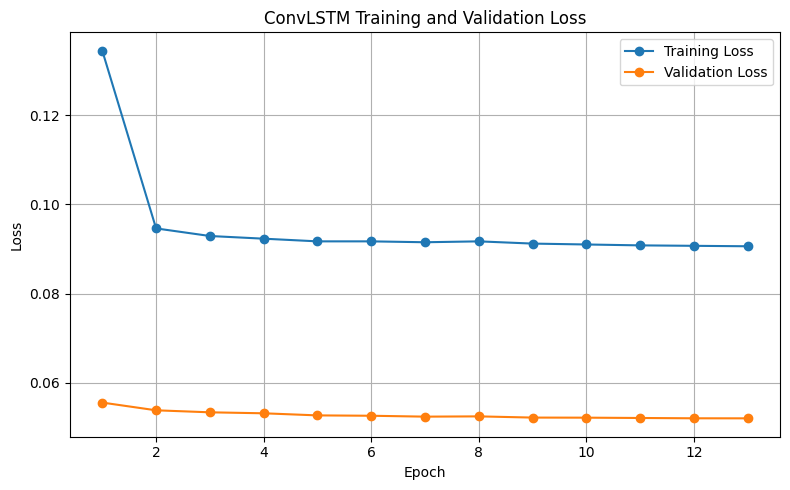

✓ 训练损失曲线已保存：
/content/ConvLSTM_results/ConvLSTM_loss_curve.png


In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_data["loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history_data["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ConvLSTM Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

loss_fig = "/content/ConvLSTM_results/ConvLSTM_loss_curve.png"

plt.savefig(
    loss_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ 训练损失曲线已保存：")
print(loss_fig)

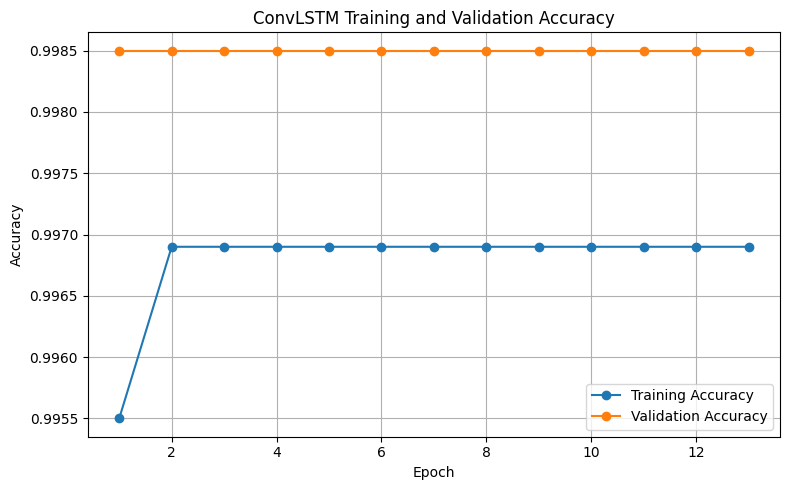

✓ 训练准确率曲线已保存：
/content/ConvLSTM_results/ConvLSTM_accuracy_curve.png


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_data["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history_data["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ConvLSTM Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()

acc_fig = "/content/ConvLSTM_results/ConvLSTM_accuracy_curve.png"

plt.savefig(
    acc_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✓ 训练准确率曲线已保存：")
print(acc_fig)

In [ ]:
model_info = """
============================================================
岗位04：ConvLSTM 模型训练与预测结果
============================================================

一、模型基本信息
模型名称：ConvLSTM 城市扩张预测模型
任务：城市建设用地扩张预测
研究区域：芜湖市
预测验证期：2016–2020

二、输入数据
历史建设用地年份：2000–2020
时间窗口：连续5年
空间切片大小：128 × 128
切片步长：64 pixels

输入变量：
1. Built-up
2. slope_deg_norm
3. pop_density_2010_norm
4. dist_road_motorway_norm
5. dist_road_trunk_norm
6. dist_road_primary_norm
7. dist_road_secondary_norm
8. dist_city_center_norm
9. dist_town_nearest_norm
10. poi_kernel_density_norm

输入通道数：10

三、ConvLSTM模型结构

Input
↓
ConvLSTM2D
Filters = 16
Kernel = 3 × 3
Padding = same
Return sequences = True
↓
ConvLSTM2D
Filters = 8
Kernel = 3 × 3
Padding = same
Return sequences = False
↓
Conv2D
Filters = 1
Kernel = 1 × 1
Activation = Sigmoid
↓
Predicted probability

模型总参数量：21,993
模型大小约：85.91 KB

四、训练设置

训练目标年份：2005–2015
验证目标年份：2016–2020

数据划分：
按时间划分
不进行随机划分

Loss：
Dice Loss + Weighted Binary Cross Entropy

Weighted BCE：
Positive class weight = 5.0

Optimizer：
Adam

Learning rate：
1 × 10^-3

数据增强：
随机90°、180°、270°旋转
水平翻转
垂直翻转

Early Stopping：
monitor = val_loss
patience = 5

五、预测方法

采用Rolling Prediction（滚动预测）。

2016年：
输入2011–2015年真实建设用地

2017年：
输入2012–2016年，其中2016年使用模型预测结果

2018年：
输入2013–2017年

2019年：
输入2014–2018年

2020年：
输入2015–2019年

每年按照模型预测概率选择最高的18,589个候选像元作为新增建设用地。

六、建设用地增长约束

年度新增建设像元：
18,589 pixels/year

像元大小：
30 m × 30 m

年度新增面积：
约16.7301 km²/year

水体约束：
禁止新增建设用地进入水体区域。

七、正式训练结果

正式训练完成：
Epoch 1–13

最佳验证损失：
Val Loss ≈ 0.05206

最佳模型：
best_convlstm_formal.keras

八、预测结果

完成2016–2020年滚动预测。

每年新增建设用地：
18,589 pixels

2016年累计建设像元：
595,750

2017年累计建设像元：
614,339

2018年累计建设像元：
632,928

2019年累计建设像元：
651,517

2020年累计建设像元：
670,106

九、最终评价

ConvLSTM平均指标：

OA：
0.989991

Kappa：
0.932058

IoU：
0.883435

FoM：
0.883435

Change_FoM：
0.016342
（2017–2020）

十、与Logistic模型比较

指标             Logistic       ConvLSTM

OA               0.9872         0.9900
Kappa            0.9139         0.9321
IoU              0.8543         0.8834
FoM              0.8543         0.8834
Change_FoM       0.0123         0.0163

Change_FoM相对提升：
32.87%

十一、交付内容

1. best_convlstm_formal.keras
2. training_history.json
3. ConvLSTM_metrics.xlsx
4. 2016–2020年Built结果
5. 2016–2020年New Built结果
6. 2016–2020年Probability结果
7. Training Loss Curve
8. Training Accuracy Curve

============================================================
"""

info_path = "/content/ConvLSTM_results/model_info.txt"

with open(info_path, "w", encoding="utf-8") as f:
    f.write(model_info)

print("✓ 模型说明文件已生成：")
print(info_path)

✓ 模型说明文件已生成：
/content/ConvLSTM_results/model_info.txt


In [ ]:
import os

result_dir = "/content/ConvLSTM_results"

print("========== ConvLSTM 最终结果 ==========")

for root, dirs, files in os.walk(result_dir):
    for file in sorted(files):
        path = os.path.join(root, file)
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f"{file:<45} {size_mb:>10.2f} MB")

print("\n✓ 文件检查完成")

========== ConvLSTM 最终结果 ==========
ConvLSTM_accuracy_curve.png                         0.12 MB
ConvLSTM_built_2016.tif                             0.30 MB
ConvLSTM_built_2017.tif                             0.30 MB
ConvLSTM_built_2018.tif                             0.26 MB
ConvLSTM_built_2019.tif                             0.26 MB
ConvLSTM_built_2020.tif                             0.30 MB
ConvLSTM_loss_curve.png                             0.10 MB
ConvLSTM_metrics.xlsx                               0.01 MB
ConvLSTM_newbuilt_2016.tif                          0.13 MB
ConvLSTM_newbuilt_2017.tif                          0.12 MB
ConvLSTM_newbuilt_2018.tif                          0.04 MB
ConvLSTM_newbuilt_2019.tif                          0.04 MB
ConvLSTM_newbuilt_2020.tif                          0.12 MB
ConvLSTM_probability_2016.tif                      36.35 MB
ConvLSTM_probability_2017.tif                      36.29 MB
ConvLSTM_probability_2018.tif                      27.40 MB
Conv

In [ ]:
import os
import shutil

result_dir = "/content/ConvLSTM_results"

files_to_copy = [
    "/content/best_convlstm_formal.keras",
    "/content/training_history.json"
]

print("========== 检查正式模型与训练记录 ==========")

for src in files_to_copy:
    if os.path.exists(src):
        dst = os.path.join(result_dir, os.path.basename(src))
        shutil.copy2(src, dst)

        size_mb = os.path.getsize(dst) / 1024 / 1024

        print(f"✓ {os.path.basename(src)}")
        print(f"  大小：{size_mb:.2f} MB")
    else:
        print(f"❌ 找不到：{src}")

print("\n✓ 复制完成")

========== 检查正式模型与训练记录 ==========
✓ best_convlstm_formal.keras
  大小：0.28 MB
✓ training_history.json
  大小：0.00 MB

✓ 复制完成


In [ ]:
import os

result_dir = "/content/ConvLSTM_results"

print("========== 最终交付文件 ==========")

files = sorted(os.listdir(result_dir))

for i, file in enumerate(files, 1):
    path = os.path.join(result_dir, file)

    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f"{i:02d}. {file:<45} {size_mb:>10.2f} MB")

print("\n文件总数：", len(files))

========== 最终交付文件 ==========
01. ConvLSTM_accuracy_curve.png                         0.12 MB
02. ConvLSTM_built_2016.tif                             0.30 MB
03. ConvLSTM_built_2017.tif                             0.30 MB
04. ConvLSTM_built_2018.tif                             0.26 MB
05. ConvLSTM_built_2019.tif                             0.26 MB
06. ConvLSTM_built_2020.tif                             0.30 MB
07. ConvLSTM_loss_curve.png                             0.10 MB
08. ConvLSTM_metrics.xlsx                               0.01 MB
09. ConvLSTM_newbuilt_2016.tif                          0.13 MB
10. ConvLSTM_newbuilt_2017.tif                          0.12 MB
11. ConvLSTM_newbuilt_2018.tif                          0.04 MB
12. ConvLSTM_newbuilt_2019.tif                          0.04 MB
13. ConvLSTM_newbuilt_2020.tif                          0.12 MB
14. ConvLSTM_probability_2016.tif                      36.35 MB
15. ConvLSTM_probability_2017.tif                      36.29 MB
16. ConvLST

In [ ]:
import os
import shutil
import zipfile

src = "/content/ConvLSTM_results"

delivery = "/content/岗位04_ConvLSTM_最终交付"

# 如果之前存在旧目录，先删除
if os.path.exists(delivery):
    shutil.rmtree(delivery)

# 创建交付目录
folders = [
    "01_模型",
    "02_训练记录",
    "03_预测结果/built",
    "03_预测结果/newbuilt",
    "03_预测结果/probability",
    "04_评价",
    "05_模型说明"
]

for folder in folders:
    os.makedirs(os.path.join(delivery, folder), exist_ok=True)


# =========================
# 1. 模型
# =========================

shutil.copy2(
    os.path.join(src, "best_convlstm_formal.keras"),
    os.path.join(delivery, "01_模型", "best_convlstm_formal.keras")
)


# =========================
# 2. 训练记录
# =========================

for file in [
    "training_history.json",
    "ConvLSTM_loss_curve.png",
    "ConvLSTM_accuracy_curve.png"
]:
    shutil.copy2(
        os.path.join(src, file),
        os.path.join(delivery, "02_训练记录", file)
    )


# =========================
# 3. 预测结果
# =========================

for year in range(2016, 2021):

    shutil.copy2(
        os.path.join(
            src,
            f"ConvLSTM_built_{year}.tif"
        ),
        os.path.join(
            delivery,
            "03_预测结果",
            "built",
            f"ConvLSTM_built_{year}.tif"
        )
    )

    shutil.copy2(
        os.path.join(
            src,
            f"ConvLSTM_newbuilt_{year}.tif"
        ),
        os.path.join(
            delivery,
            "03_预测结果",
            "newbuilt",
            f"ConvLSTM_newbuilt_{year}.tif"
        )
    )

    shutil.copy2(
        os.path.join(
            src,
            f"ConvLSTM_probability_{year}.tif"
        ),
        os.path.join(
            delivery,
            "03_预测结果",
            "probability",
            f"ConvLSTM_probability_{year}.tif"
        )
    )


# =========================
# 4. 评价
# =========================

shutil.copy2(
    os.path.join(src, "ConvLSTM_metrics.xlsx"),
    os.path.join(
        delivery,
        "04_评价",
        "ConvLSTM_metrics.xlsx"
    )
)


# =========================
# 5. 模型说明
# =========================

shutil.copy2(
    os.path.join(src, "model_info.txt"),
    os.path.join(
        delivery,
        "05_模型说明",
        "model_info.txt"
    )
)


# =========================
# 生成 ZIP
# =========================

zip_path = "/content/岗位04_ConvLSTM_最终交付.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

with zipfile.ZipFile(
    zip_path,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for root, dirs, files in os.walk(delivery):

        for file in files:

            file_path = os.path.join(root, file)

            arcname = os.path.relpath(
                file_path,
                "/content"
            )

            zipf.write(
                file_path,
                arcname
            )


# =========================
# 最终检查
# =========================

print("========================================")
print("岗位04最终交付包")
print("========================================")

file_count = 0

for root, dirs, files in os.walk(delivery):

    for file in files:
        file_count += 1

print(f"交付文件数量：{file_count}")

print("\n目录结构：")

for root, dirs, files in os.walk(delivery):

    level = root.replace(delivery, "").count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in sorted(files):

        file_path = os.path.join(root, file)

        size_mb = os.path.getsize(file_path) / 1024 / 1024

        print(
            f"{indent}    {file} "
            f"({size_mb:.2f} MB)"
        )

zip_size = os.path.getsize(zip_path) / 1024 / 1024

print("\n========================================")
print(f"ZIP大小：{zip_size:.2f} MB")
print(f"ZIP位置：{zip_path}")
print("========================================")

岗位04最终交付包
交付文件数量：21

目录结构：
岗位04_ConvLSTM_最终交付/
    05_模型说明/
        model_info.txt (0.00 MB)
    04_评价/
        ConvLSTM_metrics.xlsx (0.01 MB)
    03_预测结果/
        built/
            ConvLSTM_built_2016.tif (0.30 MB)
            ConvLSTM_built_2017.tif (0.30 MB)
            ConvLSTM_built_2018.tif (0.26 MB)
            ConvLSTM_built_2019.tif (0.26 MB)
            ConvLSTM_built_2020.tif (0.30 MB)
        probability/
            ConvLSTM_probability_2016.tif (36.35 MB)
            ConvLSTM_probability_2017.tif (36.29 MB)
            ConvLSTM_probability_2018.tif (27.40 MB)
            ConvLSTM_probability_2019.tif (27.36 MB)
            ConvLSTM_probability_2020.tif (36.10 MB)
        newbuilt/
            ConvLSTM_newbuilt_2016.tif (0.13 MB)
            ConvLSTM_newbuilt_2017.tif (0.12 MB)
            ConvLSTM_newbuilt_2018.tif (0.04 MB)
            ConvLSTM_newbuilt_2019.tif (0.04 MB)
            ConvLSTM_newbuilt_2020.tif (0.12 MB)
    02_训练记录/
        ConvLSTM_accuracy_curve.png 

下载以及备份

In [ ]:
from google.colab import files

files.download("/content/岗位04_ConvLSTM_最终交付.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

In [ ]:
import shutil
import os

src = "/content/岗位04_ConvLSTM_最终交付.zip"
dst = "/content/drive/MyDrive/岗位04_ConvLSTM_最终交付.zip"

shutil.copy2(src, dst)

print("✓ 已上传到 Google Drive")
print("位置：")
print(dst)

print("文件大小：")
print(f"{os.path.getsize(dst) / 1024 / 1024:.2f} MB")

✓ 已上传到 Google Drive
位置：
/content/drive/MyDrive/岗位04_ConvLSTM_最终交付.zip
文件大小：
159.14 MB


In [ ]:
from google.colab import files

files.download("/content/best_convlstm_formal.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("/content/training_history.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil
import os
from google.colab import files

# ConvLSTM_results 文件夹
src = "/content/ConvLSTM_results"

# 压缩后的文件
base_name = "/content/ConvLSTM_results_完整备份"

# 压缩
shutil.make_archive(
    base_name,
    "zip",
    src
)

zip_path = base_name + ".zip"

print("✓ 压缩完成")
print("文件：", zip_path)
print(f"大小：{os.path.getsize(zip_path) / 1024 / 1024:.2f} MB")

# 下载
files.download(zip_path)

✓ 压缩完成
文件： /content/ConvLSTM_results_完整备份.zip
大小：159.14 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os
import shutil

# Google Drive 中的目标文件夹
drive_dir = "/content/drive/MyDrive/Wuhu_ConvLSTM"

os.makedirs(drive_dir, exist_ok=True)

# 按你截图中的文件，原样备份
files_to_backup = [
    "training_history.json",
    "best_convlstm_formal.keras",
    "岗位04_ConvLSTM_最终交付.zip",
    "ConvLSTM_results_backup.zip",
    "ConvLSTM_results_完整备份.zip"
]

print("========== 开始备份 ==========")

for filename in files_to_backup:

    src = os.path.join("/content", filename)
    dst = os.path.join(drive_dir, filename)

    if not os.path.exists(src):
        print(f"❌ 找不到：{filename}")
        continue

    shutil.copy2(src, dst)

    size_mb = os.path.getsize(dst) / 1024 / 1024

    print(f"✓ {filename}")
    print(f"  大小：{size_mb:.2f} MB")

print("\n================================")
print("✓ 全部备份完成")
print("================================")
print("Google Drive：")
print(drive_dir)

========== 开始备份 ==========
✓ training_history.json
  大小：0.00 MB
✓ best_convlstm_formal.keras
  大小：0.28 MB
✓ 岗位04_ConvLSTM_最终交付.zip
  大小：159.14 MB
✓ ConvLSTM_results_backup.zip
  大小：0.47 MB
✓ ConvLSTM_results_完整备份.zip
  大小：159.14 MB

✓ 全部备份完成
Google Drive：
/content/drive/MyDrive/Wuhu_ConvLSTM
